# Estratégias para lidar com dados desbalanceados em problemas de classificação

Caderno didático em Python — **Esfinge**.

O percurso segue **fundamentos → criação do dataset → modelos → resolução do problema → apêndice matemático → glossário → referências**. Cada título ocupa uma célula própria. Antes de cada código, explica-se o que será feito; depois, interpreta-se o resultado.

O problema é uma **triagem de peças**, isto é, uma primeira seleção para decidir quais peças precisam de inspeção. Os dados são simulados. Comparam-se cinco estratégias: regressão logística sem alterar os exemplos de treino (**baseline**, ou referência de comparação), RandomUnderSampler, Tomek Links, RandomOverSampler e SMOTE. Antes disso, apresentam-se KNN, árvore e floresta para explicar maneiras diferentes de classificar.

Os termos técnicos aparecem acompanhados de explicações em linguagem comum. O **Apêndice A** reúne as fórmulas e explica como lê-las. O **Apêndice B** funciona como um dicionário rápido: apresenta definições curtas e indica a seção em que cada assunto é desenvolvido.

Para executar o notebook desde o começo, utiliza-se **Restart Kernel and Run All** — reiniciar o ambiente de execução e executar todas as células. As bibliotecas, ou conjuntos de ferramentas prontas, devem estar instaladas. Os comentários numéricos em Markdown descrevem a execução entregue; se os dados ou as configurações forem alterados, esses comentários também precisam ser revistos. Os números entre colchetes, como [1], indicam as fontes listadas ao final.

## 1. Fundamentos

### 1.1 Dados e seus tipos

Um **dataset**, ou conjunto de dados, reúne exemplos que serão estudados. Neste caso, cada exemplo representa uma peça. Uma **observação** é uma linha da tabela; um **atributo**, também chamado característica ou covariável, é uma informação sobre essa peça, registrada em uma coluna. Uma medida de tamanho poderia ser um atributo em um caso real [1, seção 1.1].

As informações de entrada ficam em `X`. Por reunir linhas e colunas, `X` é uma **matriz**, semelhante a uma tabela de números. A resposta conhecida fica em `y`: uma lista de valores, ou **vetor**. Essa resposta é chamada **alvo**; o valor atribuído a cada exemplo é seu **rótulo**. Aqui, o rótulo 0 significa “peça conforme”, isto é, sem o defeito considerado, e 1 significa “peça defeituosa”.

Isso é **aprendizado supervisionado**: durante o treino, fornecem-se exemplos junto com suas respostas conhecidas. O objetivo é encontrar uma regra que funcione também em peças ainda não vistas. Essa capacidade se chama **generalização** [1, seção 7.1].

| Termo técnico | Explicação e exemplo |
|---|---|
| Dado quantitativo | Expressa uma medida ou contagem, como comprimento ou número de peças. |
| Dado categórico | Indica um grupo, como “conforme” ou “defeituosa”. |
| Classificação | Prevê um grupo ou categoria. |
| Regressão | Prevê um valor numérico, como o comprimento esperado de uma peça. |
| Classificação binária | Há duas classes possíveis, como 0 e 1 neste exercício. |
| Classificação multiclasse | Há mais de duas classes, e cada exemplo recebe uma delas. |
| Classificação multirrótulo | Um exemplo pode receber vários rótulos, como vários tipos de defeito simultaneamente. |

Os números 0 e 1 são nomes de classes: 1 não significa “uma unidade de defeito”. Em dados reais, também é preciso procurar **valores ausentes** (informações não preenchidas), **duplicatas** (registros repetidos) e erros de medição. **Imputação** é o preenchimento de valores ausentes por uma regra, como usar uma média calculada no treino. O dataset deste exercício já terá entradas numéricas completas.

### 1.2 Dados desbalanceados: classes minoritária e majoritária

Há **desbalanceamento de classes** quando um grupo aparece muito mais que outro. **Frequência** é a quantidade de vezes que uma classe aparece; sua frequência relativa é essa quantidade dividida pelo total. A classe mais comum é a **majoritária**; a menos comum é a **minoritária** [1, seção 7.4].

Neste problema, chama-se **classe positiva** a que se deseja detectar: peças defeituosas. A **classe negativa** é a das peças conformes. “Positiva” não quer dizer “boa”; é apenas o nome dado à classe de interesse. A proporção de defeitos no conjunto também é chamada **prevalência**.

Por exemplo, em 100 peças com 95 conformes e 5 defeituosas, prever “conforme” para todas produz 95 acertos. A **acurácia**, ou porcentagem total de acertos, será 95%, mas nenhum defeito será encontrado. O número está correto; apenas não responde, sozinho, à pergunta importante: quantos defeitos foram detectados?

Não existe uma porcentagem que obrigue a balancear os dados. Também importam o número de defeitos disponíveis, a consequência dos erros e a semelhança entre as classes. **Sobreposição** significa que peças de classes diferentes têm características parecidas; **ruído** é a informação irrelevante ou a perturbação que dificulta reconhecer o padrão. A raridade pode refletir a realidade da população, ou seja, do conjunto de peças ao qual se pretende aplicar o modelo [1, seção 9.1].

### 1.3 Modelos, parâmetros e desempenho

Um **modelo** é uma forma de construir uma regra de previsão. **Treinar** ou **ajustar** um modelo significa usar os exemplos conhecidos para determinar essa regra. O **classificador** é o modelo usado para decidir a classe de uma peça [1, seção 7.2].

Há dois tipos de configuração importantes. **Parâmetros** são valores aprendidos durante o treino: por exemplo, a importância numérica dada a cada atributo na regressão logística. **Hiperparâmetros** são escolhas feitas antes de um ajuste: por exemplo, quantos vizinhos o KNN consulta ou quantas perguntas uma árvore pode fazer. Comparar essas escolhas exige exemplos que não tenham participado do ajuste correspondente [1, seção 1.6].

Um modelo pode produzir um **escore**, isto é, um número que indica o quanto a peça parece pertencer à classe positiva. O **limiar de decisão** é o ponto de corte para emitir o alerta. Se o limiar for 0,5, um escore de 0,7 gera alerta e um de 0,3 não gera.

Mudar esse corte pode mudar os alertas sem mudar a ordem dos escores. **Ordenação** é colocar as peças da mais suspeita para a menos suspeita. Já **calibração de probabilidades** é fazer as probabilidades previstas corresponderem às frequências observadas: entre muitas peças com previsão próxima de 20%, espera-se encontrar aproximadamente 20% de defeitos. Ordenar bem, decidir bem em um corte e estimar bem probabilidades são tarefas relacionadas, mas diferentes [1, seções 9.1–9.2].

Nas bibliotecas, também se usa a palavra **estimador** para uma ferramenta que aprende uma regra ou obtém uma estimativa a partir dos dados; um classificador é um exemplo.

### 1.4 Risco, viés e variância

**Perda** é uma pontuação que representa o erro em um exemplo. **Risco** é a perda média esperada em exemplos novos. Como não se conhecem todas as peças futuras, calcula-se uma média com os exemplos disponíveis: isso é o **risco empírico**, ou risco estimado pela amostra [1, seções 7.1–7.2].

Um resultado bom no treino não basta. Um estudante pode decorar as respostas de uma lista e ter dificuldade em questões novas; de modo semelhante, um modelo pode guardar detalhes dos exemplos sem aprender uma regra útil para outros casos.

**Viés**, no sentido estatístico usado aqui, é uma limitação sistemática da regra. Uma regra simples demais pode deixar de captar um padrão importante: isso é **subajuste**. **Variância do modelo** é a sensibilidade ao conjunto usado para aprender: ao trocar a amostra, a regra pode mudar bastante. Uma regra muito flexível pode se adaptar até aos detalhes sem importância do treino: isso é **sobreajuste** [1, seção 7.3].

Com poucos defeitos, cada exemplo tem grande influência. Repetir dez vezes a mesma peça defeituosa não equivale a observar dez peças diferentes. O apêndice separa duas fontes de dificuldade: a limitação da família de regras (**erro de aproximação**) e a dificuldade de aprender uma boa regra com os exemplos disponíveis (**erro de estimação**).

### 1.5 Função perda e custos dos erros

A **função perda** transforma um resultado em uma penalização numérica. Na **perda 0–1**, acertar vale 0 e errar vale 1. Assim, deixar passar um defeito e emitir um falso alerta recebem a mesma penalização [1, seção 7.1].

A regressão logística usa a **perda logarítmica**, ou log loss. Ela considera a probabilidade atribuída à resposta verdadeira. Se uma peça é defeituosa, prever 90% de chance de defeito recebe penalização menor que prever apenas 1%. **Otimizar** significa procurar valores dos parâmetros que reduzam essa penalização; não significa garantir um modelo perfeito [1, seção 8.1.2].

A perda usada para aprender não precisa ser a única medida usada para avaliar. Neste exercício, a avaliação dará maior importância a um **falso negativo** — deixar um defeito passar — que a um **falso positivo** — pedir inspeção para uma peça conforme. Essa diferença é chamada **assimetria dos custos**, pois os dois tipos de erro não têm o mesmo peso [1, seção 9.1].

Outra possibilidade seria usar **pesos de classe**, fazendo cada exemplo de uma classe contribuir mais para o treino. Isso não será aplicado na comparação principal. Aumentar o peso da classe rara é uma escolha de aprendizado, não uma maneira de descobrir automaticamente o custo real dos erros.

### 1.6 Matriz de confusão

A **matriz de confusão** é uma tabela que cruza a resposta verdadeira com a prevista. Aqui, as linhas indicam o que a peça realmente é; as colunas indicam o que o modelo previu. A tabela do livro usa a orientação inversa, chamada **transposta**: linhas e colunas trocam de posição, mas o significado dos quatro resultados não muda [1, seção 7.4].

| Classe verdadeira \ Previsão | Conforme (0) | Defeituosa (1) |
|---|---|---|
| Conforme (0) | **VN — verdadeiro negativo:** uma peça conforme foi corretamente liberada. | **FP — falso positivo:** houve um alerta desnecessário. |
| Defeituosa (1) | **FN — falso negativo:** um defeito passou sem alerta. | **VP — verdadeiro positivo:** o defeito foi encontrado. |

Um alerta, portanto, pode ser correto (VP) ou falso (FP). A ausência de alerta também pode estar correta (VN) ou esconder um defeito (FN).

É importante mostrar quantidades junto com porcentagens. Acertar 1 de 2 defeitos e acertar 100 de 200 produzem os mesmos 50%, mas o segundo resultado foi observado em muito mais exemplos.

### 1.7 Métricas: o que significa um bom resultado?

Uma **métrica** é uma medida usada para avaliar o resultado. Cada métrica responde a uma pergunta diferente [1, seção 7.4]:

| Métrica | Pergunta em linguagem comum |
|---|---|
| **Acurácia** | De todas as peças, quantas foram classificadas corretamente? |
| **Recall ou sensibilidade** | De todos os defeitos existentes, quantos foram encontrados? |
| **Especificidade** | De todas as peças conformes, quantas foram corretamente liberadas? |
| **Precisão** | De todos os alertas emitidos, quantos realmente indicavam defeitos? |

**Exemplo de leitura:** se existem 10 defeitos e o modelo encontra 8, o recall é 80%. Se, para encontrar esses 8, emite 20 alertas, a precisão é 40%. Há boa recuperação de defeitos, mas muitas inspeções desnecessárias. Aqui, “precisão” é o nome dessa métrica específica, não um sinônimo de acurácia.

A **acurácia balanceada** faz a média da recuperação das duas classes: uma classe numerosa não recebe mais importância apenas por ter mais exemplos. **F1** reúne precisão e recall em uma **média harmônica**, uma média que fica baixa quando uma das duas medidas é baixa. **F2** também combina ambas, mas dá mais importância ao recall. O número 2 não significa que um erro custe o dobro do outro [1, seção 7.4; 13].

Há também medidas que observam vários pontos de corte. A **curva precisão–recall** mostra como muda a qualidade dos alertas quando se tenta encontrar mais defeitos. A **AP — average precision**, ou precisão média, resume essa curva. Seu cálculo usa os aumentos de recall; não é simplesmente calcular a área com trapézios entre os pontos [14]. A **curva ROC** compara o recall com a **taxa de falsos positivos**, isto é, a fração das peças conformes que gerou alerta. **ROC-AUC** é a área sob essa curva [1, seção 9.1; 13].

AP e ROC-AUC recebem os escores, não apenas os rótulos 0 e 1: precisam saber quais peças parecem mais suspeitas. O objetivo principal deste notebook será reduzir o custo dos erros, definido na próxima seção. As demais medidas ajudarão a entender como essa redução foi obtida.

### 1.8 Treino, validação e teste

Os dados serão separados em três partes, cada uma com uma função [1, seção 7.2]:

| Parte | Função | Comparação com o estudo para uma prova |
|---|---|---|
| **Treino** | Aprender a regra a partir de exemplos conhecidos. | Exercícios usados para estudar. |
| **Validação** | Comparar as estratégias depois do treino. | Um simulado para orientar escolhas. |
| **Teste** | Avaliar a escolha final em exemplos ainda não usados para decidir. | A prova final. |

Consultar o teste para escolher o método seria como adaptar a preparação às respostas da própria prova final. Isso gera uma avaliação **otimista**, isto é, melhor do que se deveria esperar em casos realmente novos.

A divisão será de 60% para treino, 20% para validação e 20% para teste. Será também **estratificada**: cada parte terá aproximadamente a mesma porcentagem de defeitos. Uma parte da divisão também pode ser chamada **partição**.

Os exemplos simulados serão tratados como **independentes**: não são medições repetidas da mesma peça. Em dados reais, observações da mesma pessoa, peça ou equipamento precisam ser separadas por grupo; em **dados temporais**, deve-se respeitar a ordem do tempo. Manter a proporção de classes não resolve essas dependências.

A **validação cruzada** repete a avaliação, revezando partes do treino que ficam de fora de cada ajuste. Cada uma dessas partes é uma **dobra**. Neste notebook, usa-se uma única validação separada para facilitar o acompanhamento; por isso, não se demonstra que os resultados sejam estáveis em diferentes divisões.

### 1.9 Padronização, vizinhança e vazamento de dados

A **escala** descreve a ordem de grandeza dos valores de um atributo. Se uma coluna tiver valores perto de 1 e outra perto de 10.000, a segunda pode dominar uma comparação baseada em diferenças numéricas. Isso não quer dizer que ela seja mais importante.

A **padronização** coloca os atributos em uma referência comparável: subtrai sua **média** e divide pelo **desvio-padrão**, uma medida de quanto os valores se espalham em torno da média [15]. Por exemplo, um valor 12 em uma coluna com média 10 e desvio 2 vira `(12 − 10) / 2 = 1`. Ele está um desvio-padrão acima da média.

Isso ajuda métodos que usam **vizinhança**, ou seja, procuram exemplos com atributos parecidos: KNN, SMOTE e Tomek Links. A proximidade é medida por uma **distância** calculada a partir dos atributos. Padronizar também ajuda a regressão logística com regularização, explicada na seção 3.4. Árvores fazem comparações dentro de cada atributo e não precisam dessa transformação para suas divisões.

**Vazamento de dados** é o uso, durante o aprendizado, de informações que deveriam ficar reservadas para a avaliação. Se uma peça for duplicada antes de separar treino e teste, uma cópia pode aparecer em cada parte. A avaliação deixaria de representar uma peça realmente nova. Criar exemplos sintéticos antes da separação também pode causar esse problema [9].

A **pipeline** é uma sequência de etapas executadas em ordem. Neste caso: calcular a escala no treino, reamostrar o treino e ajustar o classificador. **Reamostrar** significa mudar quais exemplos aparecem ou quantas vezes aparecem na amostra; alguns métodos também criam exemplos sintéticos. Durante a previsão, a pipeline aplica a escala já aprendida e o classificador, sem reamostrar validação ou teste [10].

## 2. Criação do dataset

### 2.1 Problema: triagem de peças defeituosas

Uma fábrica fictícia deseja decidir quais peças devem passar por uma inspeção adicional. Essa primeira seleção é uma **triagem**. Cada peça recebe seis indicadores numéricos. O alvo é **0 = conforme** ou **1 = defeituosa**. Na simulação, a resposta correta representa o resultado de uma inspeção de referência. Ao usar o modelo em uma peça nova, estariam disponíveis apenas os indicadores, não o resultado dessa inspeção.

Os dados são **sintéticos**: criados por um programa para o exercício. Os indicadores são **adimensionais**, ou seja, não estão em centímetros, graus ou outra unidade física. Seus nomes genéricos evitam atribuir aos números um significado que não foi medido. A simulação permite estudar uma associação entre indicadores e classes, mas não uma **relação causal**: não demonstra que um indicador cause um defeito.

| Elemento | Definição do experimento |
|---|---|
| Unidade de observação | Uma peça simulada. |
| Entradas | Seis indicadores numéricos sem unidade física. |
| Classe positiva | Peça defeituosa: o caso que se quer detectar. |
| Ação após um alerta | Encaminhar a peça à inspeção adicional. |
| Falso negativo | Deixar passar uma peça defeituosa. |
| Falso positivo | Pedir inspeção desnecessária para uma peça conforme. |
| Critério de escolha | Menor custo de erros por 1.000 peças na validação. |
| Comparação principal | Manter classificador e limiar; mudar apenas os exemplos usados no treino. |

Antes de observar os resultados, definem-se custos fictícios: **10 unidades por falso negativo** e **1 unidade por falso positivo**. Acertos têm custo zero nessa conta simplificada. Usa-se `(10 × FN + FP) / número de peças × 1000`. Por exemplo, perder 2 defeitos e emitir 5 falsos alertas em 100 peças custa `20 + 5 = 25` unidades, equivalentes a 250 unidades por 1.000 peças. As unidades não representam dinheiro real; servem para dar importância diferente aos erros [1, seção 9.1].

Será considerado um ganho reduzir esse custo em relação ao **baseline**, a referência sem reamostragem. Também serão observados precisão e recall, pois um ganho pode vir acompanhado de mais falsos alertas. Todos os métodos usarão limiar 0,5 para comparar apenas o efeito da reamostragem. A possibilidade de mudar o limiar está no apêndice matemático.

### 2.2 Ambiente e bibliotecas

Uma **biblioteca** é um conjunto de ferramentas prontas de programação. Neste notebook, `numpy` trabalha com listas e tabelas de números; `pandas` organiza os dados em tabelas; `matplotlib` desenha gráficos; `scikit-learn` fornece classificadores e medidas de desempenho; e `imbalanced-learn` fornece os métodos de reamostragem.

Em um notebook, uma **célula de código** contém instruções Python; uma **célula Markdown** contém texto, tabelas ou fórmulas. O **kernel** é o processo que executa o código e mantém as variáveis na memória. A instalação segue [2]. Se as bibliotecas faltarem, pode-se retirar o `#` do começo da linha de instalação abaixo, executá-la e reiniciar o kernel. Retirar esse sinal se chama **descomentar**.

In [1]:
# Executar apenas se as bibliotecas ainda não estiverem instaladas:
%pip install numpy pandas matplotlib scikit-learn imbalanced-learn ipykernel

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


A linha de instalação começa com `#`, por isso funciona como comentário e não é executada. Com as bibliotecas disponíveis, a próxima célula importa as ferramentas, isto é, torna suas funções acessíveis ao código.

Ela também define a **semente aleatória**: um número usado como ponto de partida dos sorteios do programa. Usar a mesma semente ajuda a repetir os mesmos sorteios. As versões das bibliotecas são registradas porque versões diferentes podem produzir pequenas mudanças.

Cada valor fornecido a uma função é um **argumento**. `display`, usado nas células, pede ao notebook que mostre uma tabela ou outro resultado de forma legível.

Uma **variável**, como `X` ou `y`, é um nome que permite guardar ou acessar um valor, uma tabela ou outro objeto no código.

In [2]:
import sys
from time import perf_counter
from importlib.metadata import version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import clone
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, average_precision_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve,
)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks

SEMENTE = 42
CUSTO_FN, CUSTO_FP = 10, 1
LIMIAR = 0.5
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
plt.rcParams.update({'figure.figsize': (8, 4), 'font.size': 11})
print('Python:', sys.version.split()[0])
display(pd.Series({p: version(p) for p in [
    'numpy', 'pandas', 'matplotlib', 'scikit-learn', 'imbalanced-learn'
]}, name='Versão'))
analises = {}

Python: 3.13.7


numpy                2.5.3
pandas               3.0.5
matplotlib          3.11.2
scikit-learn         1.9.1
imbalanced-learn    0.14.2
Name: Versão, dtype: str

As versões exibidas identificam as ferramentas usadas nesta execução. A semente contribui para a **reprodutibilidade**, ou possibilidade de repetir o experimento e obter os mesmos resultados nas mesmas condições. Nesta etapa, apenas se preparou o ambiente: nenhum modelo foi treinado e nenhum arquivo de dados externo foi consultado.

### 2.3 Como os exemplos serão gerados

A função `make_classification` cria exemplos para um problema de classificação [12]. Serão 5.000 peças, cada uma com seis atributos:

| Atributos | Papel no exercício |
|---|---|
| Indicadores 1 e 2: **informativos** | Contêm padrões usados na construção das classes. |
| Indicadores 3 e 4: **redundantes** | São combinações dos informativos; reapresentam informação já existente. |
| Indicadores 5 e 6: **de ruído** | Não receberam informação planejada para distinguir as classes. |

`shuffle=False` mantém essa ordem das colunas. Isso não significa que os indicadores representem seis sensores reais independentes; trata-se apenas da maneira de gerar o exercício.

A proporção inicial será 95% conformes e 5% defeituosas. `flip_y=0.01` permite sortear novamente o rótulo de uma pequena parte dos exemplos, imitando erros ou incerteza na marcação das classes. O novo sorteio pode manter o rótulo anterior, por isso essa opção não significa que exatamente 1% mudará de classe. A proporção final de defeitos também pode mudar um pouco. A separação moderada dos grupos permite **sobreposição**: peças de classes diferentes podem ter indicadores parecidos.

No código, `X` é organizado como um **DataFrame**, uma tabela do pandas. `y` é uma **Series**, uma coluna de valores com identificação das linhas. A tabela `dados` junta entradas e resposta apenas para apresentação. A coluna `defeito` não entra em `X`, pois fornecer a própria resposta ao modelo tornaria a tarefa artificialmente fácil.

In [3]:
X_array, y_array = make_classification(
    n_samples=5000, n_features=6, n_informative=2, n_redundant=2,
    n_repeated=0, n_classes=2, n_clusters_per_class=2,
    weights=[0.95, 0.05], flip_y=0.01, class_sep=1.0,
    shuffle=False, random_state=SEMENTE,
)
X = pd.DataFrame(X_array, columns=[f'indicador_{i}' for i in range(1, 7)])
y = pd.Series(y_array, index=X.index, name='defeito')
dados = X.assign(defeito=y)
display(dados.head())
print('Peças:', len(X), '| Atributos de entrada:', X.shape[1])
print('Ausências nas entradas:', X.isna().sum().sum())
print('Duplicatas de atributos:', X.duplicated().sum())
assert X.notna().all().all() and set(y.unique()) == {0, 1}
assert 'defeito' not in X.columns
analises['dataset'] = (
    f'Foram criadas **{len(X)} peças** e **{X.shape[1]} atributos de entrada**. '
    f'O alvo contém **{int(y.sum())} defeitos ({y.mean():.1%})**. '
    'As verificações não encontraram entradas ausentes ou duplicadas nesta execução. '
    'As primeiras linhas mostram indicadores adimensionais, não medidas com unidades físicas. '
    'A raridade está presente, mas ainda não se mediu a capacidade de detectar defeitos.'
)

,indicador_1,indicador_2,indicador_3,indicador_4,indicador_5,indicador_6,defeito
0,-1.059163,-1.282178,-0.403085,-0.053914,-0.714807,1.794525,0
1,-2.535842,-2.750099,-0.875799,-0.338204,1.544841,0.604097,0
2,-0.715781,-0.624101,-0.204720,-0.194998,1.361007,0.064791,0
3,-2.221772,-2.876568,-0.897752,0.009223,0.765437,1.477720,0
4,-1.296808,-1.067515,-0.353254,-0.394623,0.245499,-0.255187,0


Peças: 5000 | Atributos de entrada: 6
Ausências nas entradas: 0
Duplicatas de atributos: 0


Foram criadas **5000 peças** e **6 atributos de entrada**. O alvo contém **265 defeitos (5,3%)**. As verificações não encontraram entradas ausentes ou duplicadas nesta execução. As primeiras linhas mostram indicadores adimensionais, não medidas com unidades físicas. A raridade está presente, mas ainda não se mediu a capacidade de detectar defeitos.

### 2.4 Separação das amostras

Primeiro, reservam-se 20% das peças para teste. Dos 80% restantes, separam-se 25% para validação: isso corresponde a 20% do total. Assim, ficam 60% para treino, 20% para validação e 20% para teste.

`stratify` pede que cada parte mantenha aproximadamente a proporção de classes. Os **índices**, identificações das linhas, permitem conferir se uma peça apareceu em mais de uma parte. O comando `assert` verifica uma condição e interrompe a execução se ela não for atendida.

A tabela de contagens abaixo serve apenas para conferir a divisão. A exploração dos atributos usará somente o treino, e não se farão previsões de teste antes de escolher a estratégia.

In [4]:
X_dev, X_teste, y_dev, y_teste = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEMENTE)
X_treino, X_val, y_treino, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=SEMENTE)
assert set(X_treino.index).isdisjoint(X_val.index)
assert set(X_treino.index).isdisjoint(X_teste.index)
assert set(X_val.index).isdisjoint(X_teste.index)

def contagem(alvo):
    n = pd.Series(alvo).value_counts().reindex([0, 1], fill_value=0)
    return {'conformes': int(n[0]), 'defeituosas': int(n[1]),
            'total': int(n.sum()), 'fração de defeitos': n[1] / n.sum()}

display(pd.DataFrame({nome: contagem(alvo) for nome, alvo in [
    ('Treino', y_treino), ('Validação', y_val), ('Teste', y_teste)
]}).T)
analises['divisao'] = (
    f'O treino possui **{len(y_treino)} peças**, com **{int(y_treino.sum())} defeitos**; '
    f'a validação e o teste possuem **{len(y_val)}** e **{len(y_teste)} peças**, '
    f'com **{int(y_val.sum())}** e **{int(y_teste.sum())} defeitos**, respectivamente. '
    'Os índices são disjuntos. As proporções permanecem próximas: a avaliação não foi '
    'artificialmente balanceada. Isso permite interpretar os alertas no cenário raro simulado.'
)

,conformes,defeituosas,total,fração de defeitos
Treino,2841.0,159.0,3000.0,0.053
Validação,947.0,53.0,1000.0,0.053
Teste,947.0,53.0,1000.0,0.053


O treino possui **3000 peças**, com **159 defeitos**; a validação e o teste possuem **1000** e **1000 peças**, com **53** e **53 defeitos**, respectivamente. Nenhum índice de peça aparece em duas partes: os conjuntos são disjuntos, isto é, sem elementos em comum. As proporções permanecem próximas: a avaliação não foi artificialmente balanceada. Isso permite interpretar os alertas no cenário raro simulado.

### 2.5 Explorando o problema no treino

A tabela descritiva resume os valores de cada coluna. A **média** indica um valor central; o **desvio-padrão** indica quanto os valores variam; a **amplitude** é a diferença entre o maior e o menor valor. A saída também apresenta **quartis**: valores que delimitam os primeiros 25%, 50% e 75% dos dados ordenados. O quartil de 50% é a **mediana**, o valor central nessa ordem.

O gráfico de barras conta peças de cada classe. No **gráfico de dispersão**, cada ponto representa uma peça e sua posição depende de dois indicadores. Mostrar só duas das seis colunas é fazer uma **projeção**: uma visão parcial dos dados. Os modelos continuarão usando as seis colunas, não apenas o que aparece no desenho.

,indicador_1,indicador_2,indicador_3,indicador_4,indicador_5,indicador_6
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,-0.03,-0.90,-0.25,0.56,0.02,0.03
std,1.28,1.07,0.31,1.17,1.02,0.99
min,-4.54,-5.45,-1.70,-4.95,-3.86,-3.33
25%,-1.02,-1.58,-0.43,-0.26,-0.66,-0.63
50%,0.13,-0.92,-0.25,0.13,0.02,0.03
75%,1.00,-0.28,-0.07,1.39,0.71,0.69
max,3.20,4.64,1.20,5.07,3.38,3.94


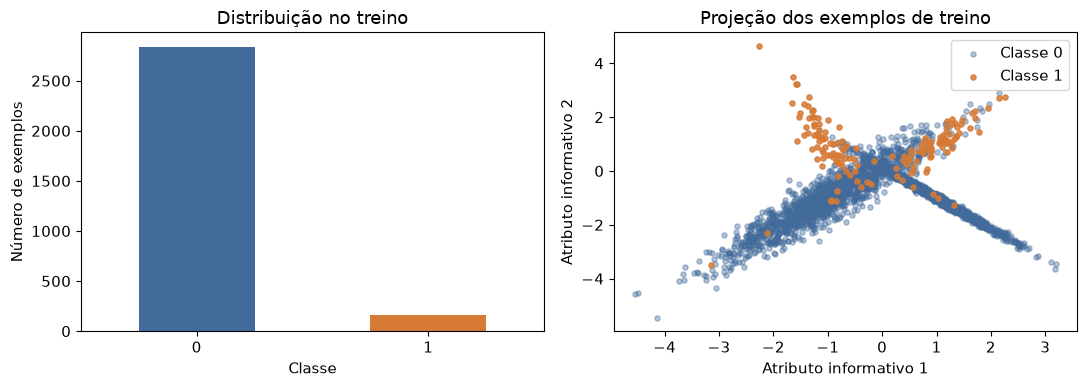

In [5]:
display(X_treino.describe().round(2))
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
y_treino.value_counts().sort_index().plot.bar(
    ax=axs[0], color=['#426b9b', '#d67a36'], rot=0)
axs[0].set(xlabel='Classe', ylabel='Número de exemplos', title='Distribuição no treino')
for classe, cor in [(0, '#426b9b'), (1, '#d67a36')]:
    mascara = y_treino == classe
    axs[1].scatter(X_treino.loc[mascara, 'indicador_1'],
                   X_treino.loc[mascara, 'indicador_2'],
                   s=14, alpha=0.4 if classe == 0 else 0.85,
                   c=cor, label=f'Classe {classe}')
axs[1].set(xlabel='Atributo informativo 1', ylabel='Atributo informativo 2',
           title='Projeção dos exemplos de treino')
axs[1].legend()
plt.tight_layout()
plt.show()

As barras mostram que os defeitos são raros. A dispersão mostra regiões em que pontos das duas classes ficam misturados: nem sempre as peças podem ser distinguidas olhando apenas esses dois indicadores.

Os indicadores redundantes repetem parte da informação existente, enquanto os de ruído podem atrapalhar comparações por distância. Portanto, o problema não se resume a igualar as barras: também é preciso aprender a distinguir exemplos parecidos.

## 3. Modelos de classificação

Cada modelo será primeiro explicado, depois treinado e, por fim, avaliado na validação. Assim, será possível acompanhar diferentes maneiras de decidir se uma peça parece defeituosa.

Na seção 4, a regressão logística será mantida fixa, mesmo que outro modelo se saia melhor aqui. O objetivo daquela comparação será responder: **o que muda quando se alteram os exemplos de treino, mantendo a mesma regra de aprendizado?**

### 3.1 Como medir resultados e efetividade

A **função** abaixo reúne instruções que serão reutilizadas. Ela recebe os escores e aplica o limiar 0,5 para produzir alertas. Depois, conta os acertos e erros, calcula as métricas e aplica o custo por 1.000 peças.

**Efetividade preditiva** significa, neste exercício, a capacidade de encontrar defeitos e reduzir o custo dos erros. **Eficiência computacional** trata dos recursos usados para chegar ao resultado, como tempo de treino e quantidade de exemplos. Um modelo pode ser rápido e detectar poucos defeitos, ou demorar mais e ter melhor resultado.

`perf_counter` funciona como um cronômetro. O tempo informado inclui o ajuste da pipeline, mas não os gráficos nem as previsões. Como há apenas uma medição e ela depende da máquina, não se trata de um **benchmark**, uma comparação de desempenho feita sob condições controladas e repetidas.

AP e ROC-AUC usam os escores. Para precisão e F-scores, há casos sem divisão possível: por exemplo, se nenhum alerta foi emitido, a precisão teria denominador zero. `zero_division=0` manda mostrar zero nesses casos. É uma regra de apresentação; não significa que tenha sido possível medir a qualidade de alertas inexistentes.

In [6]:
def avaliar(alvo, escores, limiar=LIMIAR):
    previsto = (np.asarray(escores) >= limiar).astype(int)
    vn, fp, fn, vp = confusion_matrix(alvo, previsto, labels=[0, 1]).ravel()
    custo = CUSTO_FN * fn + CUSTO_FP * fp
    return {
        'acurácia': accuracy_score(alvo, previsto),
        'precisão': precision_score(alvo, previsto, zero_division=0),
        'recall': recall_score(alvo, previsto, zero_division=0),
        'especificidade': vn / (vn + fp),
        'acurácia balanceada': balanced_accuracy_score(alvo, previsto),
        'F1': f1_score(alvo, previsto, zero_division=0),
        'F2': fbeta_score(alvo, previsto, beta=2, zero_division=0),
        'AP': average_precision_score(alvo, escores),
        'ROC-AUC': roc_auc_score(alvo, escores),
        'VN': int(vn), 'FP': int(fp), 'FN': int(fn), 'VP': int(vp),
        'custo / 1.000 peças': 1000 * custo / len(alvo),
    }

modelos_didaticos, resultados_modelos = {}, {}

def registrar_modelo(nome, modelo, segundos):
    r = avaliar(y_val, modelo.predict_proba(X_val)[:, 1])
    modelos_didaticos[nome] = modelo
    resultados_modelos[nome] = {**r, 'ajuste (s)': segundos}
    quadro = pd.DataFrame([resultados_modelos[nome]], index=[nome])
    display(quadro[['acurácia', 'precisão', 'recall', 'especificidade', 'F2', 'AP']].round(3))
    display(quadro[['VP', 'FN', 'FP', 'VN', 'custo / 1.000 peças', 'ajuste (s)']].round(3))
    analises['modelo_' + nome] = (
        f'Na validação, **{nome}** detectou **{r["VP"]} de {int(y_val.sum())} defeitos**, '
        f'deixou passar **{r["FN"]}**; a quantidade de falsos alertas foi **{r["FP"]}**. '
        f'O recall foi **{r["recall"]:.1%}**, a precisão **{r["precisão"]:.1%}** e '
        f'o custo **{r["custo / 1.000 peças"]:.0f} unidades por 1.000 peças**. '
        f'O ajuste levou cerca de **{segundos:.3f} s** nesta execução. '
        'Esses valores devem ser julgados pelo custo e pelos tipos de erro, não apenas pela acurácia.'
    )

As funções foram preparadas, mas ainda não treinaram modelos. Reutilizar a mesma função de avaliação é como usar a mesma régua em todas as medições: a classe positiva, o limiar e o custo dos erros serão iguais em cada comparação.

### 3.2 Referência ingênua: sempre prever peça conforme

`DummyClassifier(strategy='most_frequent')` procura a classe mais comum no treino e responde sempre com ela. Aqui, seria como um inspetor que liberasse todas as peças sem examinar seus indicadores. Essa **referência ingênua** ajuda a perceber por que uma acurácia alta pode esconder a falta de detecção de defeitos [1, seção 7.4].

Ela tem função ilustrativa. O baseline principal da seção 4 será a regressão logística sem reamostragem, que de fato usa os atributos para aprender uma regra.

In [7]:
inicio = perf_counter()
modelo_dummy = DummyClassifier(strategy='most_frequent')
modelo_dummy.fit(X_treino, y_treino)
tempo_dummy = perf_counter() - inicio
registrar_modelo('Referência ingênua', modelo_dummy, tempo_dummy)

,acurácia,precisão,recall,especificidade,F2,AP
Referência ingênua,0.947,0.0,0.0,1.0,0.0,0.053


,VP,FN,FP,VN,custo / 1.000 peças,ajuste (s)
Referência ingênua,0,53,0,947,530.0,0.002


Na validação, **Referência ingênua** detectou **0 de 53 defeitos**, deixou passar **53** e teve **0** como número de falsos alertas. O recall (porcentagem dos defeitos encontrados) foi **0,0%**, a precisão (porcentagem dos alertas que estavam corretos) **0,0%** e o custo **530 unidades por 1.000 peças**. O ajuste levou cerca de **0,001 s** nesta execução. Esses valores devem ser julgados pelo custo e pelos tipos de erro, não apenas pela acurácia.

Mesmo que a acurácia pareça alta, prever sempre “conforme” não atende ao objetivo: o recall de defeitos é zero. Todas as peças defeituosas atravessam a triagem sem alerta, e o custo dos falsos negativos permanece integral.

### 3.3 K vizinhos mais próximos (KNN)

**KNN** significa *k-nearest neighbors*, ou **k vizinhos mais próximos**. Para avaliar uma peça nova, o método procura no treino as peças com indicadores mais parecidos e observa seus rótulos [1, seção 8.6]. “Próximos” se refere à distância entre os números dos atributos, não à posição física das peças.

Com **votos uniformes**, cada vizinho tem a mesma importância. Por exemplo, se 9 dos 15 vizinhos forem defeituosos, o escore de defeito será `9 / 15 = 0,6`; com limiar 0,5, haverá alerta. Esse exemplo explica a regra, não é um resultado medido do dataset.

Poucos vizinhos podem tornar a resposta muito dependente de uma ou duas peças; vizinhos demais podem fazer um grupo pequeno de defeitos se perder entre as peças conformes. A pipeline abaixo padroniza os dados e usa **15 vizinhos**, número definido antes da avaliação. O treino do KNN guarda os exemplos; boa parte do trabalho acontece depois, quando é preciso procurar vizinhos para prever uma peça nova. Por isso, seu tempo de ajuste sozinho não mede todo o esforço do método.

In [8]:
inicio = perf_counter()
modelo_knn = Pipeline([
    ('escala', StandardScaler()),
    ('modelo', KNeighborsClassifier(n_neighbors=15)),
])
modelo_knn.fit(X_treino, y_treino)
tempo_knn = perf_counter() - inicio
registrar_modelo('KNN', modelo_knn, tempo_knn)

,acurácia,precisão,recall,especificidade,F2,AP
KNN,0.966,0.952,0.377,0.999,0.429,0.578


,VP,FN,FP,VN,custo / 1.000 peças,ajuste (s)
KNN,20,33,1,946,331.0,0.019


Na validação, **KNN** detectou **20 de 53 defeitos**, deixou passar **33** e teve **1** como número de falsos alertas. O recall (porcentagem dos defeitos encontrados) foi **37,7%**, a precisão (porcentagem dos alertas que estavam corretos) **95,2%** e o custo **331 unidades por 1.000 peças**. O ajuste levou cerca de **0,004 s** nesta execução. Esses valores devem ser julgados pelo custo e pelos tipos de erro, não apenas pela acurácia.

### 3.4 Regressão logística

A **regressão logística** combina os atributos dando uma importância numérica a cada um. Essas importâncias são os **coeficientes**, aprendidos no treino. Também há um valor inicial, o **intercepto**, que participa da conta mesmo quando os atributos valem zero. Somar os atributos multiplicados por seus coeficientes é fazer uma **combinação linear** [1, seção 8.1.2].

Essa soma passa pela **função sigmoide**, uma curva em forma de S que transforma qualquer número em um valor entre 0 e 1. Esse valor é usado como escore de defeito. Apesar de “regressão” no nome, a decisão final é uma classificação: comparar o escore com 0,5 para emitir ou não um alerta.

A **fronteira de decisão** é a separação entre as regiões em que o modelo dá respostas diferentes. Na regressão logística, ela é linear no espaço dos atributos usados: com dois atributos, pode ser uma reta. Isso pode dificultar a separação de grupos com formas mais complexas.

O ajuste usará **regularização L2**, uma penalização que desestimula coeficientes muito grandes. Ela ajuda a controlar a complexidade; não garante ausência de sobreajuste. O hiperparâmetro `C=1.0` controla essa penalização: valores menores de `C` significam regularização mais forte. `max_iter=2000` limita o número de **iterações**, etapas repetidas do cálculo de ajuste [16]. A pipeline padroniza o treino antes dessa conta. Esse mesmo modelo será usado no baseline e nos quatro reamostradores.

O ajuste procura **convergência**, isto é, estabilizar o cálculo segundo uma regra de parada. O limite de iterações impede que o programa repita as etapas indefinidamente; atingir o limite não seria, por si só, prova de que encontrou uma boa solução.

In [9]:
inicio = perf_counter()
modelo_logistico = Pipeline([
    ('escala', StandardScaler()),
    ('modelo', LogisticRegression(C=1.0, max_iter=2000, random_state=SEMENTE)),
])
modelo_logistico.fit(X_treino, y_treino)
tempo_logistico = perf_counter() - inicio
registrar_modelo('Regressão logística', modelo_logistico, tempo_logistico)

,acurácia,precisão,recall,especificidade,F2,AP
Regressão logística,0.956,0.765,0.245,0.996,0.284,0.486


,VP,FN,FP,VN,custo / 1.000 peças,ajuste (s)
Regressão logística,13,40,4,943,404.0,0.022


Na validação, **Regressão logística** detectou **13 de 53 defeitos**, deixou passar **40** e teve **4** como número de falsos alertas. O recall (porcentagem dos defeitos encontrados) foi **24,5%**, a precisão (porcentagem dos alertas que estavam corretos) **76,5%** e o custo **404 unidades por 1.000 peças**. O ajuste levou cerca de **0,004 s** nesta execução. Esses valores devem ser julgados pelo custo e pelos tipos de erro, não apenas pela acurácia.

### 3.5 Árvore de classificação

Uma **árvore de classificação** funciona como uma sequência de perguntas. Por exemplo: “o indicador 1 ultrapassa certo valor?”. A resposta conduz a outra pergunta ou a uma decisão final [1, seção 8.3].

Um **nó** é um ponto dessa sequência; os **nós filhos** recebem os exemplos após uma divisão. Uma **folha** é o ponto final, no qual se usa a proporção das classes para produzir a previsão. A **profundidade** mede quantas divisões existem ao longo de um caminho desde o início.

O **índice de Gini**, ou impureza de Gini, mede o quanto as classes estão misturadas em um nó. Um grupo só de peças conformes tem impureza zero; um grupo misto tem impureza maior. A árvore procura divisões que reduzam essa mistura. Isso não significa que conheça uma explicação física para os defeitos: ela está separando os exemplos disponíveis.

A árvore abaixo terá profundidade máxima 5 e pelo menos 10 exemplos por folha. Esses limites evitam divisões excessivamente específicas, embora não garantam bom desempenho. Não será necessário padronizar, pois cada pergunta compara valores dentro de uma mesma coluna.

In [10]:
inicio = perf_counter()
modelo_arvore = DecisionTreeClassifier(
    max_depth=5, min_samples_leaf=10, random_state=SEMENTE)
modelo_arvore.fit(X_treino, y_treino)
tempo_arvore = perf_counter() - inicio
registrar_modelo('Árvore', modelo_arvore, tempo_arvore)

,acurácia,precisão,recall,especificidade,F2,AP
Árvore,0.971,0.853,0.547,0.995,0.589,0.586


,VP,FN,FP,VN,custo / 1.000 peças,ajuste (s)
Árvore,29,24,5,942,245.0,0.025


Na validação, **Árvore** detectou **29 de 53 defeitos**, deixou passar **24** e teve **5** como número de falsos alertas. O recall (porcentagem dos defeitos encontrados) foi **54,7%**, a precisão (porcentagem dos alertas que estavam corretos) **85,3%** e o custo **245 unidades por 1.000 peças**. O ajuste levou cerca de **0,011 s** nesta execução. Esses valores devem ser julgados pelo custo e pelos tipos de erro, não apenas pela acurácia.

### 3.6 Floresta aleatória

Uma **floresta aleatória** reúne várias árvores e combina suas previsões. A ideia é reduzir a dependência de uma única sequência de perguntas [1, seção 8.4].

Para criar diferenças entre as árvores, usam-se **amostras bootstrap**: sorteiam-se exemplos do treino com reposição, de modo que uma peça pode aparecer mais de uma vez e outra pode ficar de fora daquela árvore. Além disso, a cada divisão, considera-se um subconjunto de atributos escolhido aleatoriamente, ou seja, apenas parte das colunas. Assim, as árvores não são todas construídas da mesma forma.

No `RandomForestClassifier`, faz-se a média das probabilidades previstas pelas árvores [17]. Por exemplo, valores 0,2, 0,4 e 0,9 de três árvores produziriam média 0,5. Essa **agregação**, ou combinação de respostas, não é necessariamente igual a pedir apenas o voto 0 ou 1 de cada árvore.

A célula usa 120 árvores e no mínimo três exemplos por folha. A floresta será avaliada na mesma validação dos outros modelos. Combinar árvores pode ajudar, mas não garante encontrar os defeitos raros.

In [11]:
inicio = perf_counter()
modelo_floresta = RandomForestClassifier(
    n_estimators=120, min_samples_leaf=3, random_state=SEMENTE, n_jobs=1)
modelo_floresta.fit(X_treino, y_treino)
tempo_floresta = perf_counter() - inicio
registrar_modelo('Floresta', modelo_floresta, tempo_floresta)

,acurácia,precisão,recall,especificidade,F2,AP
Floresta,0.965,0.8,0.453,0.994,0.496,0.637


,VP,FN,FP,VN,custo / 1.000 peças,ajuste (s)
Floresta,24,29,6,941,296.0,1.233


Na validação, **Floresta** detectou **24 de 53 defeitos**, deixou passar **29** e teve **6** como número de falsos alertas. O recall (porcentagem dos defeitos encontrados) foi **45,3%**, a precisão (porcentagem dos alertas que estavam corretos) **80,0%** e o custo **296 unidades por 1.000 peças**. O ajuste levou cerca de **0,497 s** nesta execução. Esses valores devem ser julgados pelo custo e pelos tipos de erro, não apenas pela acurácia.

### 3.7 O que se aprendeu com os modelos?

A tabela coloca os resultados lado a lado usando as mesmas peças de validação. Isso permite observar se o tipo de regra de classificação influencia a quantidade de defeitos encontrados e o custo dos erros.

Nesta etapa, o propósito é aprender sobre os modelos; ainda não se escolhe o tratamento de reamostragem. O tempo de ajuste não inclui o tempo de previsão, o que é especialmente importante ao interpretar o KNN.

In [12]:
tabela_modelos = pd.DataFrame(resultados_modelos).T
colunas_resumo = ['precisão', 'recall', 'F2', 'AP', 'FN', 'FP', 'custo / 1.000 peças']
display(tabela_modelos[colunas_resumo + ['ajuste (s)']].round(3))
melhor_modelo_didatico = tabela_modelos['custo / 1.000 peças'].idxmin()
analises['comparacao_modelos'] = (
    f'Entre os modelos ilustrados, **{melhor_modelo_didatico}** apresentou o menor custo '
    f'na validação (**{tabela_modelos.loc[melhor_modelo_didatico, "custo / 1.000 peças"]:.0f} '
    'unidades por 1.000 peças**). Isso indica que a família do classificador também importa. '
    'Ainda assim, a próxima comparação mantém a **regressão logística**, conforme definido antes dos resultados. '
    'Trocar simultaneamente o modelo e a amostra impediria atribuir as diferenças à reamostragem.'
)

,precisão,recall,F2,AP,FN,FP,custo / 1.000 peças,ajuste (s)
Referência ingênua,0.000,0.000,0.000,0.053,53.0,0.0,530.0,0.002
KNN,0.952,0.377,0.429,0.578,33.0,1.0,331.0,0.019
Regressão logística,0.765,0.245,0.284,0.486,40.0,4.0,404.0,0.022
Árvore,0.853,0.547,0.589,0.586,24.0,5.0,245.0,0.025
Floresta,0.800,0.453,0.496,0.637,29.0,6.0,296.0,1.233


Entre os modelos ilustrados, **Árvore** apresentou o menor custo na validação (**245 unidades por 1.000 peças**). Isso indica que a família do classificador também importa. Ainda assim, a próxima comparação mantém a **regressão logística**, conforme definido antes dos resultados. Trocar simultaneamente o modelo e a amostra impediria atribuir as diferenças à reamostragem.

## 4. Resolução do problema

A comparação seguirá a ordem **baseline → RandomUnderSampler → Tomek Links → RandomOverSampler → SMOTE**. Todos usarão as mesmas colunas, as mesmas divisões de dados, a mesma regressão logística e o mesmo limiar. A diferença estará nos exemplos apresentados durante o treino.

Será escolhido o menor custo por 1.000 peças na validação. Se houver empate, terá preferência o maior recall, isto é, a maior recuperação de defeitos. Se o empate continuar, mantém-se o primeiro método da ordem acima. Definir essas regras antes de olhar os resultados evita mudar o critério para favorecer uma conclusão. O teste só será consultado após a escolha.

### 4.1 Como observar a ação dos métodos

A função auxiliar fará duas tarefas. Primeiro, calculará os alertas e o custo na validação. Depois, preparará uma cópia dos dados de treino para mostrar o que foi removido, repetido ou criado por cada método. Essa segunda parte usa o mesmo treino, a mesma escala e a mesma semente, sem acrescentar dados de validação ou teste ao aprendizado.

Serão mostradas as quantidades antes e depois, as medidas de desempenho e os gráficos dos exemplos. Nos gráficos, cada peça será representada por seus dois primeiros indicadores: uma **projeção em duas dimensões**, ou visão em dois eixos. O método continuará usando os seis indicadores. Para SMOTE, os pontos criados serão destacados.

No código, `clone` cria uma cópia da configuração de um método para um novo ajuste. `fit` ajusta o modelo ao treino; `fit_resample` ajusta a regra de reamostragem e devolve a amostra modificada; `transform` aplica uma transformação já aprendida; `predict_proba` produz os escores das classes.

In [13]:
metodos, resultados_val, amostras_visuais = {}, {}, {}
ORDEM = ['Baseline', 'RandomUnderSampler', 'Tomek Links', 'RandomOverSampler', 'SMOTE']

def registrar_metodo(nome, pipeline, segundos, amostrador=None):
    escores = pipeline.predict_proba(X_val)[:, 1]
    r = avaliar(y_val, escores)
    x_original = pipeline.named_steps['escala'].transform(X_treino)
    y_original = y_treino.to_numpy()
    if amostrador is None:
        xr, yr = x_original, y_original.copy()
    else:
        # Cópia auxiliar para inspeção; nenhum dado de validação é reamostrado.
        xr, yr = clone(amostrador).fit_resample(x_original, y_original)
    n = contagem(yr)
    metodos[nome] = pipeline
    amostras_visuais[nome] = (xr, yr)
    resultados_val[nome] = {**r, 'conformes no treino': n['conformes'],
                            'defeitos no treino': n['defeituosas'],
                            'n treino final': n['total'], 'ajuste (s)': segundos}
    display(pd.DataFrame([contagem(y_original), n], index=['Antes', 'Depois']))
    display(pd.DataFrame([resultados_val[nome]], index=[nome])[
        colunas_resumo + ['n treino final', 'ajuste (s)']].round(3))
    if amostrador is not None:
        fig, axs = plt.subplots(1, 3, figsize=(13, 3.8))
        contagens = pd.DataFrame({
            'Antes': [np.sum(y_original == 0), np.sum(y_original == 1)],
            'Depois': [np.sum(yr == 0), np.sum(yr == 1)],
        }, index=['Conforme', 'Defeito'])
        contagens.plot.bar(ax=axs[0], rot=0, color=['#426b9b', '#d67a36'])
        axs[0].set(title='Contagens no treino', ylabel='Peças')
        for ax, xx, yy, titulo in [
            (axs[1], x_original, y_original, 'Antes'), (axs[2], xr, yr, 'Depois')
        ]:
            for classe, cor, rotulo in [(0, '#426b9b', 'Conforme'), (1, '#d67a36', 'Defeito')]:
                mask = np.asarray(yy) == classe
                ax.scatter(xx[mask, 0], xx[mask, 1], s=9, alpha=0.35,
                           color=cor, label=rotulo)
            if nome == 'SMOTE' and titulo == 'Depois':
                novos = xx[len(x_original):]
                ax.scatter(novos[:, 0], novos[:, 1], s=9, alpha=0.3,
                           color='#39805d', label='Sintéticos')
            ax.set(title=titulo, xlabel='Indicador 1 padronizado', ylabel='Indicador 2 padronizado')
            # Mesmos limites nas duas projeções permitem comparação visual direta.
            ax.set_xlim(x_original[:, 0].min()-0.2, x_original[:, 0].max()+0.2)
            ax.set_ylim(x_original[:, 1].min()-0.2, x_original[:, 1].max()+0.2)
            ax.legend(fontsize=8)
        fig.suptitle(nome)
        plt.tight_layout()
        plt.show()
    if nome == 'Baseline':
        comparacao = 'Essa será a referência fixa para julgar os quatro tratamentos.'
    else:
        diferenca = r['custo / 1.000 peças'] - resultados_val['Baseline']['custo / 1.000 peças']
        verbo = 'reduziu' if diferenca < 0 else 'aumentou' if diferenca > 0 else 'manteve'
        comparacao = (f'Em relação ao baseline, o método **{verbo} o custo**'
                      + (f' em **{abs(diferenca):.0f} unidades por 1.000 peças**.' if diferenca else '.'))
    analises['metodo_' + nome] = (
        f'O treino apresentado ao classificador contém **{n["conformes"]} conformes** e '
        f'**{n["defeituosas"]} defeitos** (**{n["total"]} exemplos**). '
        f'Na validação, **{nome}** detectou **{r["VP"]} de {int(y_val.sum())} defeitos**, '
        f'perdeu **{r["FN"]}** e produziu **{r["FP"]} falsos alertas**. '
        f'A precisão foi **{r["precisão"]:.1%}**, o recall **{r["recall"]:.1%}** '
        f'e o custo **{r["custo / 1.000 peças"]:.0f} unidades por 1.000 peças**. '
        f'{comparacao} O ajuste levou aproximadamente **{segundos:.3f} s**; '
        'a reconstrução da figura e as previsões não estão incluídas nesse tempo.'
    )

A função deixa a avaliação pronta, mas não escolhe um vencedor. As cópias feitas para desenhar os gráficos seguem os mesmos dados e sorteios, uma reconstrução **determinística** nessas condições. O conjunto de validação continua com as mesmas peças em todas as chamadas: só o treino é modificado.

### 4.2 Baseline: regressão logística sem reamostragem

**Baseline** significa referência de comparação. Aqui, ele é a regressão logística já treinada na seção 3.4, usando todos os exemplos originais de treino. Nenhum exemplo foi retirado, repetido ou criado. Reutiliza-se o modelo e sua avaliação, sem fazer outro ajuste.

A pergunta será: alterar a amostra melhora o resultado desse mesmo classificador? A referência ingênua da seção 3.2 respondia sempre “conforme”; este baseline usa as informações das peças para produzir previsões.

In [14]:
registrar_metodo('Baseline', modelo_logistico, tempo_logistico)

,conformes,defeituosas,total,fração de defeitos
Antes,2841,159,3000,0.053
Depois,2841,159,3000,0.053


,precisão,recall,F2,AP,FN,FP,custo / 1.000 peças,n treino final,ajuste (s)
Baseline,0.765,0.245,0.284,0.486,40,4,404.0,3000,0.022


O classificador recebeu no treino **2841 conformes** e **159 defeitos** (**3000 exemplos**). Na validação, **Baseline** detectou **13 de 53 defeitos**, perdeu **40** e produziu **4 falsos alertas**. A precisão (porcentagem dos alertas que estavam corretos) foi **76,5%**, o recall (recuperação dos defeitos) **24,5%** e o custo **404 unidades por 1.000 peças**. Essa será a referência fixa para julgar os quatro tratamentos. O ajuste levou aproximadamente **0,004 s**; a reconstrução da figura e as previsões não estão incluídas nesse tempo.

### 4.3 Under-sampling aleatório: RandomUnderSampler

**Under-sampling**, ou **subamostragem**, reduz a quantidade de exemplos de uma classe. O `RandomUnderSampler` faz essa redução por sorteio. Neste caso, serão sorteadas peças conformes e mantidos todos os defeitos [6].

O sorteio será **sem reposição**: depois de escolhida, uma peça não é escolhida novamente. `sampling_strategy=1.0` pede quantidades iguais das duas classes. Por exemplo, se o treino tiver 950 conformes e 50 defeitos, o resultado terá 50 conformes e os mesmos 50 defeitos. Esse exemplo numérico apenas ilustra a operação.

A vantagem possível é dar menos predominância às peças conformes e reduzir o número de exemplos processados. A desvantagem é descartar informação que poderia ajudar a reconhecer peças conformes diferentes entre si. A pipeline faz a sequência **padronizar → selecionar exemplos → treinar a regressão logística**. Na validação, continuam sendo usadas todas as peças originais, sem sorteio ou redução.

,conformes,defeituosas,total,fração de defeitos
Antes,2841,159,3000,0.053
Depois,159,159,318,0.500


,precisão,recall,F2,AP,FN,FP,custo / 1.000 peças,n treino final,ajuste (s)
RandomUnderSampler,0.241,0.736,0.521,0.491,14,123,263.0,318,0.028


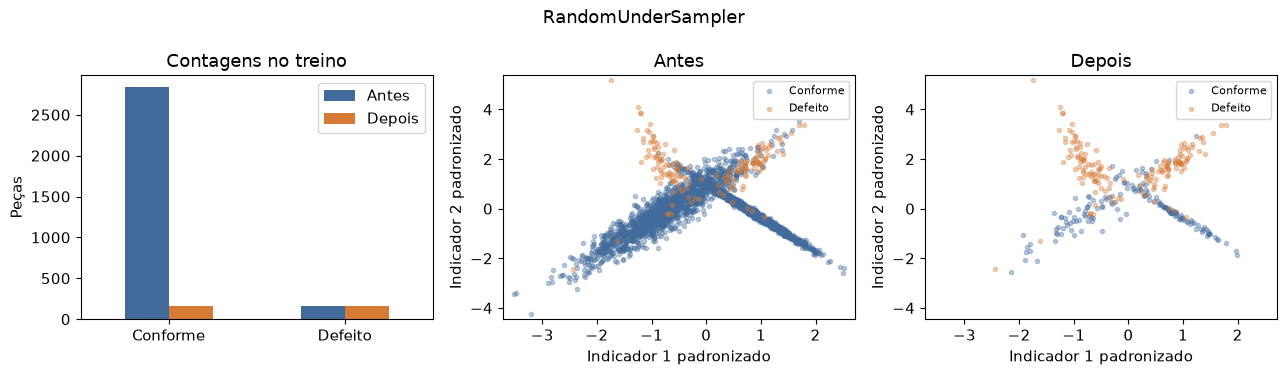

In [15]:
amostrador_under = RandomUnderSampler(
    sampling_strategy=1.0, replacement=False, random_state=SEMENTE)
modelo_under = Pipeline([
    ('escala', StandardScaler()),
    ('amostra', amostrador_under),
    ('modelo', LogisticRegression(C=1.0, max_iter=2000, random_state=SEMENTE)),
])
inicio = perf_counter()
modelo_under.fit(X_treino, y_treino)
tempo_under = perf_counter() - inicio
registrar_metodo('RandomUnderSampler', modelo_under, tempo_under, amostrador_under)

O classificador recebeu no treino **159 conformes** e **159 defeitos** (**318 exemplos**). Na validação, **RandomUnderSampler** detectou **39 de 53 defeitos**, perdeu **14** e produziu **123 falsos alertas**. A precisão (porcentagem dos alertas que estavam corretos) foi **24,1%**, o recall (recuperação dos defeitos) **73,6%** e o custo **263 unidades por 1.000 peças**. Em relação ao baseline, o método **reduziu o custo** em **141 unidades por 1.000 peças**. O ajuste levou aproximadamente **0,005 s**; a reconstrução da figura e as previsões não estão incluídas nesse tempo.

A figura mostra peças conformes sendo retiradas, sem coletar defeitos novos. Barras do mesmo tamanho confirmam a operação solicitada; não provam que o modelo melhorou. Para julgar a melhora, devem-se observar os defeitos encontrados, os falsos alertas e o custo.

Com menos exemplos, o classificador tem menos linhas para processar. Porém, quais peças conformes foram sorteadas pode influenciar bastante o que ele aprende. Outra semente pode selecionar outras peças e produzir outro resultado.

### 4.4 Under-sampling por limpeza: Tomek Links

**Tomek Links** também pode remover exemplos, mas escolhe pela proximidade entre classes, não por um sorteio de quantidade fixa. Um **par Tomek** é formado por dois exemplos de classes diferentes que são **vizinhos mais próximos mútuos**: A é o mais próximo de B, e B é o mais próximo de A [8].

Neste exercício, um par teria uma peça conforme e uma defeituosa muito parecidas nos indicadores. Com `sampling_strategy='majority'`, remove-se apenas a peça da classe majoritária, a conforme [5]. A semelhança não prova que algum rótulo esteja errado; os dois exemplos podem ser legítimos.

Esse procedimento é chamado **limpeza de amostra**. Ele não obriga as contagens a ficarem iguais: se houver poucos pares, poucas peças serão removidas. A seleção depende da **geometria dos dados**, isto é, de como os exemplos se distribuem e de suas distâncias nos seis indicadores padronizados.

,conformes,defeituosas,total,fração de defeitos
Antes,2841,159,3000,0.053000
Depois,2799,159,2958,0.053753


,precisão,recall,F2,AP,FN,FP,custo / 1.000 peças,n treino final,ajuste (s)
Tomek Links,0.765,0.245,0.284,0.486,40,4,404.0,2958,0.064


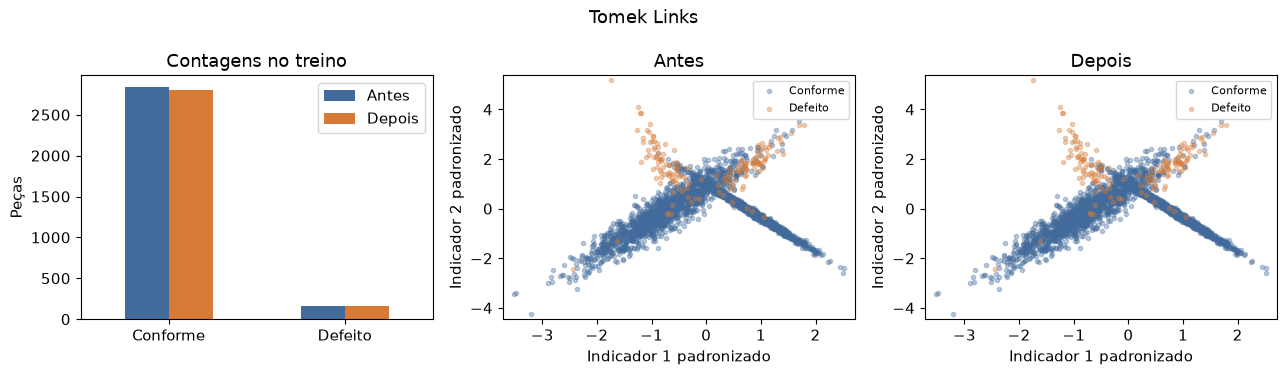

In [16]:
amostrador_tomek = TomekLinks(sampling_strategy='majority')
modelo_tomek = Pipeline([
    ('escala', StandardScaler()),
    ('amostra', amostrador_tomek),
    ('modelo', LogisticRegression(C=1.0, max_iter=2000, random_state=SEMENTE)),
])
inicio = perf_counter()
modelo_tomek.fit(X_treino, y_treino)
tempo_tomek = perf_counter() - inicio
registrar_metodo('Tomek Links', modelo_tomek, tempo_tomek, amostrador_tomek)

O classificador recebeu no treino **2799 conformes** e **159 defeitos** (**2958 exemplos**). Na validação, **Tomek Links** detectou **13 de 53 defeitos**, perdeu **40** e produziu **4 falsos alertas**. A precisão (porcentagem dos alertas que estavam corretos) foi **76,5%**, o recall (recuperação dos defeitos) **24,5%** e o custo **404 unidades por 1.000 peças**. Em relação ao baseline, o método **manteve o custo**. O ajuste levou aproximadamente **0,015 s**; a reconstrução da figura e as previsões não estão incluídas nesse tempo.

Tomek Links pode deixar quase todas as peças no treino. Isso é esperado, pois procura pares de contato entre classes, não uma proporção obrigatória de 1:1. Uma remoção também pode retirar uma peça conforme válida que se parece com um defeito.

Nesta validação, a limpeza deixou o mesmo custo do baseline. Portanto, embora tenha alterado o treino, não trouxe ganho nesse critério nesta execução. Isso não demonstra que nunca funcione em outros dados.

### 4.5 Over-sampling aleatório: RandomOverSampler

**Over-sampling**, ou **sobreamostragem**, aumenta a presença de uma classe no treino. `RandomOverSampler` faz isso repetindo exemplos da classe minoritária escolhidos por sorteio [7].

O sorteio é **com reposição**: o mesmo exemplo pode ser escolhido várias vezes. Se existissem 950 peças conformes e 50 defeitos, `sampling_strategy=1.0` completaria 950 registros de defeitos por repetições, mantendo as 950 conformes. Os 900 registros acrescentados não seriam 900 peças reais novas.

A pipeline padroniza, repete exemplos minoritários e treina o classificador. Dar mais presença aos defeitos pode mudar os alertas, mas também aumenta o conjunto processado e pode favorecer a memorização de poucos exemplos.

,conformes,defeituosas,total,fração de defeitos
Antes,2841,159,3000,0.053
Depois,2841,2841,5682,0.500


,precisão,recall,F2,AP,FN,FP,custo / 1.000 peças,n treino final,ajuste (s)
RandomOverSampler,0.252,0.717,0.523,0.504,15,113,263.0,5682,0.04


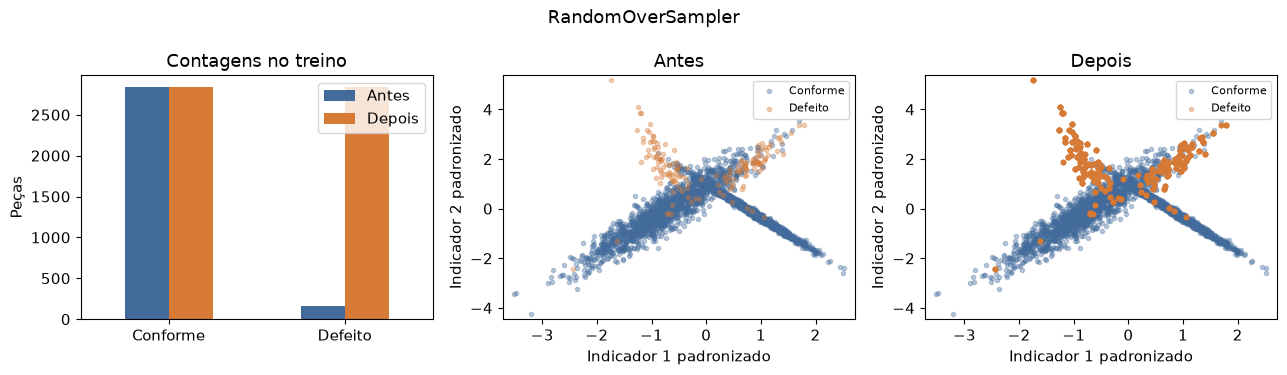

In [17]:
amostrador_over = RandomOverSampler(sampling_strategy=1.0, random_state=SEMENTE)
modelo_over = Pipeline([
    ('escala', StandardScaler()),
    ('amostra', amostrador_over),
    ('modelo', LogisticRegression(C=1.0, max_iter=2000, random_state=SEMENTE)),
])
inicio = perf_counter()
modelo_over.fit(X_treino, y_treino)
tempo_over = perf_counter() - inicio
registrar_metodo('RandomOverSampler', modelo_over, tempo_over, amostrador_over)

O classificador recebeu no treino **2841 conformes** e **2841 defeitos** (**5682 exemplos**). Na validação, **RandomOverSampler** detectou **38 de 53 defeitos**, perdeu **15** e produziu **113 falsos alertas**. A precisão (porcentagem dos alertas que estavam corretos) foi **25,2%**, o recall (recuperação dos defeitos) **71,7%** e o custo **263 unidades por 1.000 peças**. Em relação ao baseline, o método **reduziu o custo** em **141 unidades por 1.000 peças**. O ajuste levou aproximadamente **0,006 s**; a reconstrução da figura e as previsões não estão incluídas nesse tempo.

As barras mostram mais registros de defeitos. Na dispersão, muitas cópias ficam exatamente sobre os pontos originais; por isso, nem sempre se percebe visualmente quantas repetições existem.

Repetir uma informação é diferente de obter informação nova. A utilidade da repetição depende de seu efeito nos alertas e no custo, não apenas do número final de registros.

### 4.6 Over-sampling sintético: SMOTE

**SMOTE** é a sigla de *Synthetic Minority Over-sampling Technique*, uma técnica de sobreamostragem da classe minoritária. Em vez de apenas copiar, cria exemplos com valores intermediários entre dois exemplos minoritários próximos. Isso é **interpolação** [3, 7].

Por exemplo, entre pontos `(1, 2)` e `(3, 6)`, um ponto intermediário poderia ser `(2, 4)`. SMOTE escolhe uma posição no segmento que liga os pontos; não escolhe necessariamente o meio. Os pontos usados são da mesma classe minoritária.

`k_neighbors=5` define cinco vizinhos candidatos para a criação. Por isso, são necessários pelo menos seis exemplos da classe: o ponto inicial e cinco vizinhos. `sampling_strategy=1.0` pede quantidades iguais das duas classes [3].

A pipeline padroniza, cria exemplos sintéticos e treina o classificador. A conta é possível aqui porque as entradas são numéricas, mas não garante que um ponto criado represente uma peça fisicamente possível. Não faz sentido, por exemplo, tirar uma média numérica entre categorias “azul” e “verde”. Para entradas categóricas ou mistas existem variantes: **SMOTEN** para apenas categorias e **SMOTENC** para categorias junto com números [7].

,conformes,defeituosas,total,fração de defeitos
Antes,2841,159,3000,0.053
Depois,2841,2841,5682,0.500


,precisão,recall,F2,AP,FN,FP,custo / 1.000 peças,n treino final,ajuste (s)
SMOTE,0.253,0.717,0.525,0.497,15,112,262.0,5682,0.04


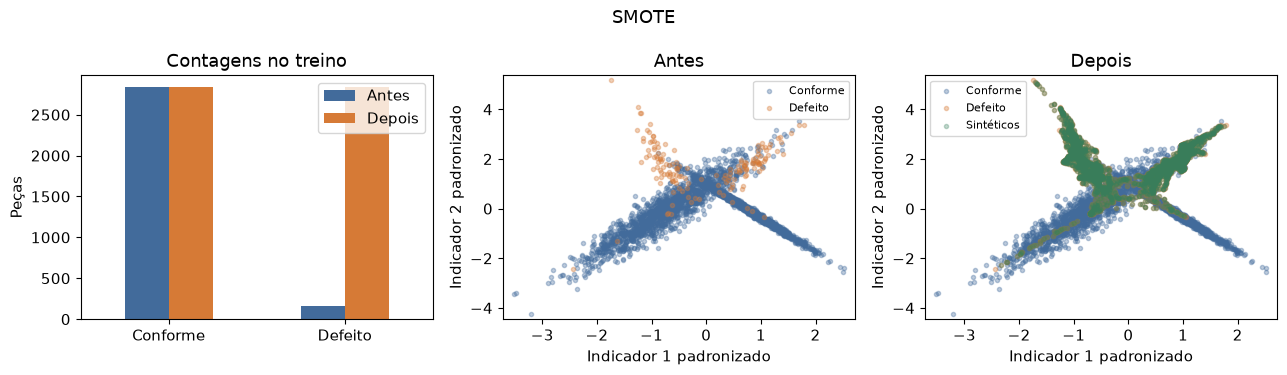

In [18]:
assert int(y_treino.sum()) >= 6
amostrador_smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=SEMENTE)
modelo_smote = Pipeline([
    ('escala', StandardScaler()),
    ('amostra', amostrador_smote),
    ('modelo', LogisticRegression(C=1.0, max_iter=2000, random_state=SEMENTE)),
])
inicio = perf_counter()
modelo_smote.fit(X_treino, y_treino)
tempo_smote = perf_counter() - inicio
registrar_metodo('SMOTE', modelo_smote, tempo_smote, amostrador_smote)

O classificador recebeu no treino **2841 conformes** e **2841 defeitos** (**5682 exemplos**). Na validação, **SMOTE** detectou **38 de 53 defeitos**, perdeu **15** e produziu **112 falsos alertas**. A precisão (porcentagem dos alertas que estavam corretos) foi **25,3%**, o recall (recuperação dos defeitos) **71,7%** e o custo **262 unidades por 1.000 peças**. Em relação ao baseline, o método **reduziu o custo** em **142 unidades por 1.000 peças**. O ajuste levou aproximadamente **0,008 s**; a reconstrução da figura e as previsões não estão incluídas nesse tempo.

Os pontos verdes representam exemplos criados pelo programa, não peças novas que foram medidas. Eles podem aparecer entre pontos originais, enquanto no RandomOverSampler as cópias ficam no mesmo lugar.

A interpolação pode passar por regiões com peças conformes. Assim, espalhar mais pontos no desenho não garante melhor separação das classes: é preciso conferir os resultados na validação.

### 4.7 Por que a razão de amostragem exige atenção?

**Razão de amostragem** é uma comparação entre quantidades das classes. Para SMOTE e os reamostradores aleatórios binários, um número decimal em `sampling_strategy` indica a quantidade minoritária dividida pela majoritária ao final. O valor 1,0 pede igualdade; 0,5 pede aproximadamente um minoritário para dois majoritários [3, 4, 6].

O parâmetro também aceita outras formas. Um **dicionário** em Python relaciona chaves a valores: neste uso, classes às contagens desejadas. Uma **string**, ou texto, como `'majority'`, seleciona a classe sobre a qual atuar. Nos métodos de limpeza, selecionar a classe não determina quantos exemplos serão removidos [5]. Esses detalhes constam na **API**, a descrição de como usar uma ferramenta e seus argumentos.

O exemplo enviado [4] contém uma fórmula textual de undersampling invertida em relação à API [6]. Usa-se a definição da API, e a próxima célula confere as contagens. Os dados modificados por essa demonstração não serão usados para escolher entre os cinco modelos.

In [19]:
linhas_razao = []
for nome, amostrador in {
    'Over 0,5': RandomOverSampler(sampling_strategy=0.5, random_state=SEMENTE),
    'Under 0,5': RandomUnderSampler(sampling_strategy=0.5, random_state=SEMENTE),
}.items():
    _, yr = amostrador.fit_resample(modelo_logistico.named_steps['escala'].transform(X_treino), y_treino)
    c = contagem(yr)
    linhas_razao.append({'método': nome, **c,
                         'minoritária/majoritária': c['defeituosas']/c['conformes']})
display(pd.DataFrame(linhas_razao).set_index('método'))
# Como o número final majoritário é 2*n_min, o under é exato neste exemplo.
assert np.isclose(linhas_razao[1]['minoritária/majoritária'], 0.5)

,conformes,defeituosas,total,fração de defeitos,minoritária/majoritária
método,,,,,
"Over 0,5",2841,1420,4261,0.333255,0.499824
"Under 0,5",318,159,477,0.333333,0.500000


A razão minoritária/majoritária próxima de 0,5 corresponde à fração minoritária próxima de 1/3 no total. Arredondamentos inteiros podem impedir uma igualdade exata no oversampling. Essa verificação sustenta a interpretação do parâmetro; ela não demonstra que a razão 0,5 seja melhor que 1,0.

### 4.8 Comparação e escolha na validação

A tabela compara o baseline e os quatro reamostradores nas mesmas peças de validação, com a proporção original de defeitos. As contagens de treino mostram quanto cada método retirou, repetiu ou criou.

A escolha procura o menor custo conforme a regra já definida. O gráfico também mostra recall: ele permite observar quanto da recuperação de defeitos foi acompanhado de uma redução de custo. Até aqui, não foram calculadas previsões para o teste.

,precisão,recall,F2,AP,FN,FP,custo / 1.000 peças
Baseline,0.765,0.245,0.284,0.486,40.0,4.0,404.0
RandomUnderSampler,0.241,0.736,0.521,0.491,14.0,123.0,263.0
Tomek Links,0.765,0.245,0.284,0.486,40.0,4.0,404.0
RandomOverSampler,0.252,0.717,0.523,0.504,15.0,113.0,263.0
SMOTE,0.253,0.717,0.525,0.497,15.0,112.0,262.0


,conformes no treino,defeitos no treino,n treino final,ajuste (s)
Baseline,2841.0,159.0,3000.0,0.022
RandomUnderSampler,159.0,159.0,318.0,0.028
Tomek Links,2799.0,159.0,2958.0,0.064
RandomOverSampler,2841.0,2841.0,5682.0,0.040
SMOTE,2841.0,2841.0,5682.0,0.040


Estratégia escolhida antes de avaliar o teste: SMOTE


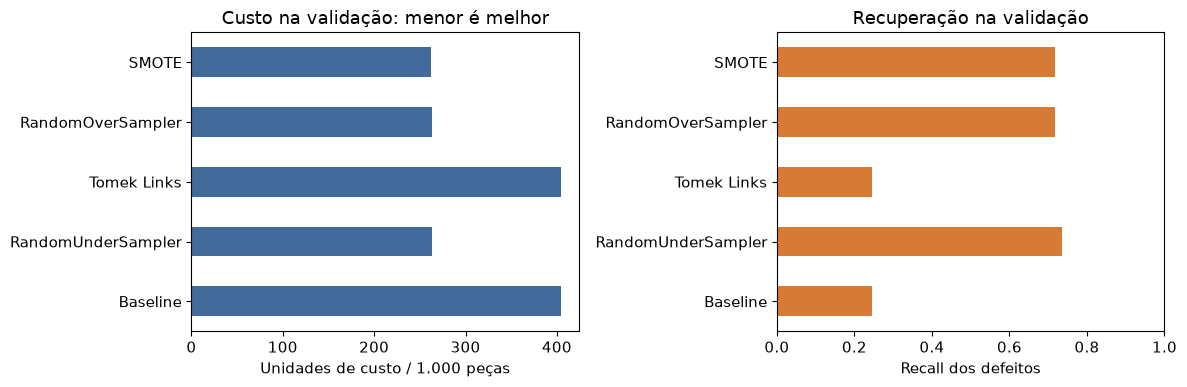

In [20]:
tabela_val = pd.DataFrame(resultados_val).T.loc[ORDEM]
display(tabela_val[colunas_resumo].round(3))
display(tabela_val[['conformes no treino', 'defeitos no treino', 'n treino final', 'ajuste (s)']].round(3))
ranking = tabela_val.assign(ordem=np.arange(len(ORDEM))).sort_values(
    ['custo / 1.000 peças', 'recall', 'ordem'], ascending=[True, False, True])
nome_escolhido = ranking.index[0]
modelo_final = metodos[nome_escolhido]
print('Estratégia escolhida antes de avaliar o teste:', nome_escolhido)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
tabela_val['custo / 1.000 peças'].plot.barh(ax=axs[0], color='#426b9b')
tabela_val['recall'].plot.barh(ax=axs[1], color='#d67a36')
axs[0].set(xlabel='Unidades de custo / 1.000 peças', title='Custo na validação: menor é melhor')
axs[1].set(xlabel='Recall dos defeitos', xlim=(0, 1), title='Recuperação na validação')
for ax in axs: ax.set_ylabel('')
plt.tight_layout()
plt.show()
r_escolhido = tabela_val.loc[nome_escolhido]
redu_val = tabela_val.loc['Baseline', 'custo / 1.000 peças'] - r_escolhido['custo / 1.000 peças']
analises['selecao'] = (
    f'A estratégia selecionada foi **{nome_escolhido}**, com custo de '
    f'**{r_escolhido["custo / 1.000 peças"]:.0f} unidades por 1.000 peças** na validação, '
    f'uma redução de **{redu_val:.0f}** em relação ao baseline. '
    f'Seu recall foi **{r_escolhido["recall"]:.1%}** e sua precisão **{r_escolhido["precisão"]:.1%}**. '
    'Essa é uma escolha sob os custos fictícios definidos, não uma classificação universal dos métodos. '
    'O mesmo modelo já ajustado no treino será levado ao teste, sem reajuste em treino + validação.'
)

A estratégia selecionada foi **SMOTE**, com custo de **262 unidades por 1.000 peças** na validação, uma redução de **142** em relação ao baseline. Seu recall (recuperação dos defeitos) foi **71,7%** e sua precisão (porcentagem dos alertas que estavam corretos) **25,3%**. Essa é uma escolha sob os custos fictícios definidos, não uma classificação universal dos métodos. O mesmo modelo já ajustado no treino será levado ao teste, sem reajuste em treino + validação. A diferença para RandomUnderSampler e RandomOverSampler foi de apenas **1 unidade de custo por 1.000 peças**. Essa margem é pequena e não sustenta afirmar que o SMOTE manteria a vantagem em outras amostras.

### 4.9 Avaliação final no teste

A estratégia já foi escolhida e não será trocada a partir desta etapa. Os cinco modelos serão avaliados no mesmo teste para registrar seus resultados finais. Mesmo que outra linha pareça melhor, a solução adotada continuará sendo a escolhida na validação.

Não se altera o limiar e não se treina novamente. Essa separação permite perguntar se o ganho observado também aparece em peças que ainda não tinham participado da escolha.

,escolhido na validação,precisão,recall,F2,AP,FN,FP,custo / 1.000 peças
Baseline,False,0.792,0.358,0.403,0.598,34.0,5.0,345.0
RandomUnderSampler,False,0.254,0.868,0.585,0.592,7.0,135.0,205.0
Tomek Links,False,0.724,0.396,0.436,0.596,32.0,8.0,328.0
RandomOverSampler,False,0.250,0.849,0.574,0.593,8.0,135.0,215.0
SMOTE,True,0.254,0.868,0.585,0.593,7.0,135.0,205.0


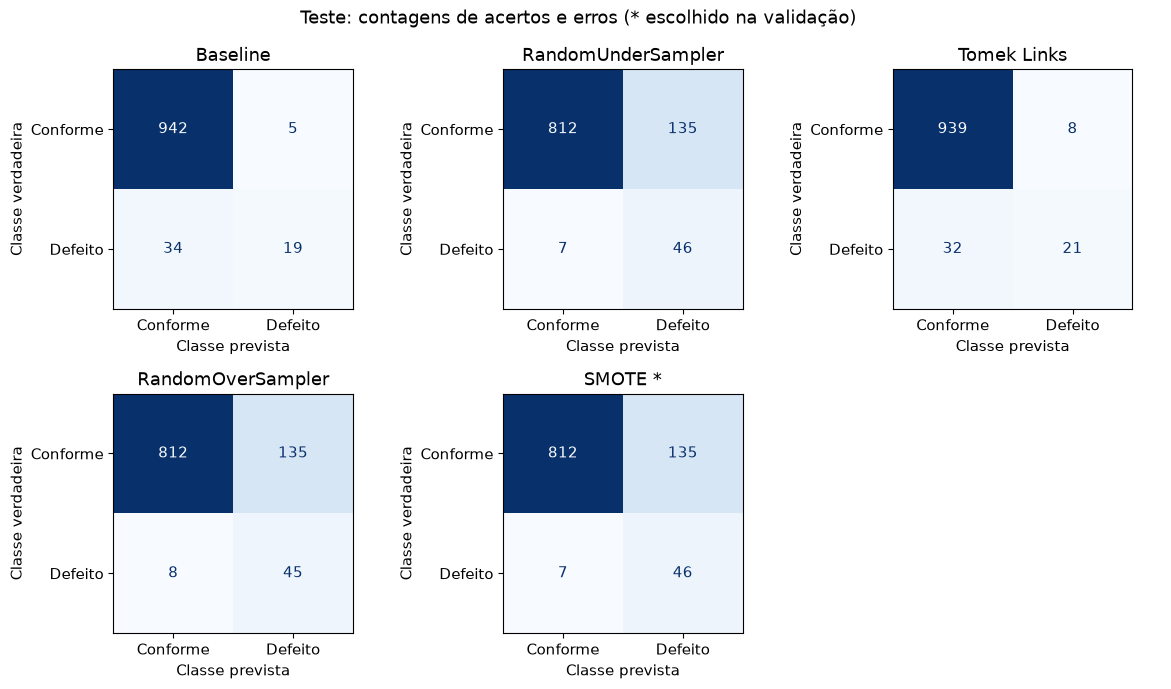

In [21]:
escores_teste = {nome: modelo.predict_proba(X_teste)[:, 1]
                 for nome, modelo in metodos.items()}
tabela_teste = pd.DataFrame({nome: avaliar(y_teste, escores_teste[nome])
                            for nome in ORDEM}).T
exibicao = tabela_teste[colunas_resumo].copy()
exibicao.insert(0, 'escolhido na validação', exibicao.index == nome_escolhido)
display(exibicao.round(3))

fig, axs = plt.subplots(2, 3, figsize=(12, 7))
for ax, nome in zip(axs.flat, ORDEM):
    ConfusionMatrixDisplay.from_predictions(
        y_teste, escores_teste[nome] >= LIMIAR, labels=[0, 1],
        display_labels=['Conforme', 'Defeito'], colorbar=False, cmap='Blues', ax=ax)
    ax.set(title=nome + (' *' if nome == nome_escolhido else ''),
           xlabel='Classe prevista', ylabel='Classe verdadeira')
axs.flat[-1].axis('off')
fig.suptitle('Teste: contagens de acertos e erros (* escolhido na validação)')
plt.tight_layout()
plt.show()

r = tabela_teste.loc[nome_escolhido]
b = tabela_teste.loc['Baseline']
delta = b['custo / 1.000 peças'] - r['custo / 1.000 peças']
conclusao = ('reduziu' if delta > 0 else 'aumentou' if delta < 0 else 'manteve')
analises['teste'] = (
    f'A solução escolhida, **{nome_escolhido}**, detectou **{int(r["VP"])} de '
    f'{int(y_teste.sum())} defeitos** no teste, deixou passar **{int(r["FN"])}** '
    f'e gerou **{int(r["FP"])} inspeções desnecessárias**. '
    f'O recall foi **{r["recall"]:.1%}** e a precisão **{r["precisão"]:.1%}**. '
    f'O custo foi **{r["custo / 1.000 peças"]:.0f}**, contra **{b["custo / 1.000 peças"]:.0f}** '
    f'do baseline: a estratégia **{conclusao} o custo**'
    + (f' em **{abs(delta):.0f} unidades por 1.000 peças**.' if delta else '.')
    + ' Esse resultado avalia a escolha feita antes de consultar o teste; '
    'as demais linhas permanecem uma comparação descritiva.'
)

A solução escolhida, **SMOTE**, detectou **46 de 53 defeitos** no teste, deixou passar **7** e gerou **135 inspeções desnecessárias**. O recall (porcentagem dos defeitos encontrados) foi **86,8%** e a precisão (porcentagem dos alertas que estavam corretos) **25,4%**. O custo foi **205**, contra **345** do baseline: a estratégia **reduziu o custo** em **140 unidades por 1.000 peças**. Esse resultado avalia a escolha feita antes de consultar o teste; as demais linhas apenas descrevem os resultados dos outros métodos. RandomUnderSampler apresentou as mesmas contagens de acertos e erros do SMOTE neste teste; isso reforça que a escolha da validação não demonstra superioridade geral de um deles.

### 4.10 Ordenação dos defeitos: curva precisão–recall

A matriz de confusão mostra o que aconteceu com o limiar 0,5. A **curva precisão–recall** amplia a observação: o que acontece ao tornar a regra mais ou menos exigente para emitir alertas?

O eixo do recall mostra quanto dos defeitos foi encontrado; o eixo da precisão mostra quanto dos alertas estava correto. A AP resume o desempenho ao longo dessa curva, mas não precisa aumentar só porque o recall em um limiar aumentou [14].

A célula desenha as cinco curvas no teste apenas para comparação. Não servirá para escolher outro método ou corte. A linha horizontal representa a proporção de defeitos no teste, que é a AP de um escore constante, igual para todas as peças.

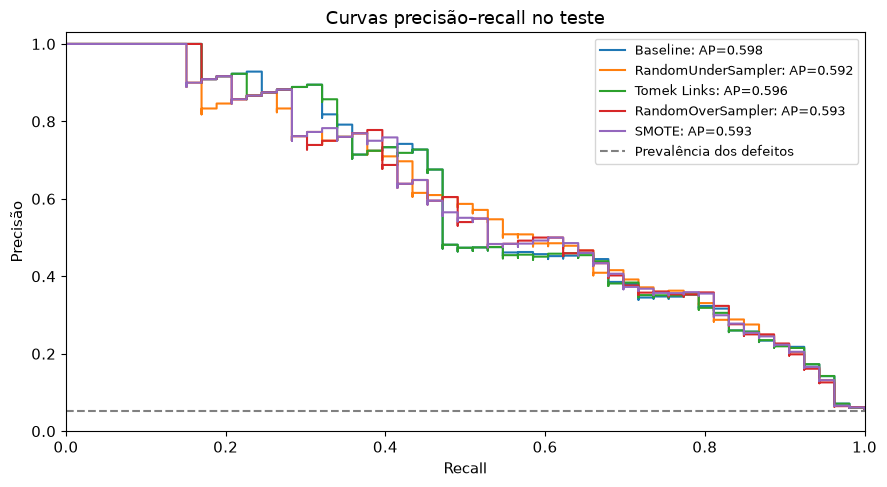

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
for nome in ORDEM:
    precisao, recall, _ = precision_recall_curve(y_teste, escores_teste[nome])
    ax.step(recall, precisao, where='post',
            label=f'{nome}: AP={tabela_teste.loc[nome, "AP"]:.3f}')
ax.axhline(y_teste.mean(), linestyle='--', color='gray', label='Prevalência dos defeitos')
ax.set(xlabel='Recall', ylabel='Precisão', xlim=(0, 1), ylim=(0, 1.03),
       title='Curvas precisão–recall no teste')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
analises['curvas'] = (
    f'O baseline teve **AP={tabela_teste.loc["Baseline", "AP"]:.3f}** e a solução '
    f'escolhida teve **AP={tabela_teste.loc[nome_escolhido, "AP"]:.3f}** no teste. '
    'AP não foi o critério de escolha: o objetivo declarado foi minimizar custo na decisão com limiar 0,5. '
    'Uma redução de custo pode coexistir com AP semelhante ou menor, pois a frequência de treinamento '
    'pode alterar a posição dos escores em relação ao limiar sem melhorar sua ordenação.'
)

O baseline teve **AP=0,598** e a solução escolhida teve **AP=0,593** no teste. AP não foi o critério de escolha: o objetivo declarado foi minimizar custo na decisão com limiar 0,5. Uma redução de custo pode coexistir com AP semelhante ou menor, pois a frequência de treinamento pode alterar a posição dos escores em relação ao limiar sem melhorar sua ordenação.

### 4.11 Resposta ao problema e limites da solução

A próxima célula reúne em uma tabela a escolha já feita e suas consequências para a triagem: quantos defeitos foram encontrados, quantos passaram e quantas inspeções foram desnecessárias. Ela apenas organiza resultados existentes; não faz novo treino nem muda a escolha.

In [23]:
r = tabela_teste.loc[nome_escolhido]
b = tabela_teste.loc['Baseline']
resposta = pd.Series({
    'Solução selecionada na validação': nome_escolhido,
    'Classificador': 'Regressão logística; C=1.0; limiar=0.5',
    'Peças no teste': len(y_teste),
    'Defeitos detectados': int(r['VP']),
    'Defeitos não detectados': int(r['FN']),
    'Inspeções desnecessárias': int(r['FP']),
    'Custo do baseline / 1.000': b['custo / 1.000 peças'],
    'Custo da solução / 1.000': r['custo / 1.000 peças'],
}, name='Resposta ao problema de triagem')
display(resposta)
analises['conclusao'] = (
    f'Para os dados, a partição e os custos adotados, a recomendação resultante do protocolo é '
    f'**{nome_escolhido} + regressão logística**. '
    f'A triagem final emitiu **{int(r["VP"] + r["FP"])} alertas em {len(y_teste)} peças**; '
    f'**{int(r["VP"])} alertas correspondiam a defeitos**. '
    'O problema foi tratado por uma regra reproduzível e avaliada em teste separado, '
    'mas os erros restantes mostram que não foi obtida uma inspeção perfeita.'
)

Solução selecionada na validação                                     SMOTE
Classificador                       Regressão logística; C=1.0; limiar=0.5
Peças no teste                                                        1000
Defeitos detectados                                                     46
Defeitos não detectados                                                  7
Inspeções desnecessárias                                               135
Custo do baseline / 1.000                                            345.0
Custo da solução / 1.000                                             205.0
Name: Resposta ao problema de triagem, dtype: object

Para os dados, a divisão dos dados e os custos adotados, a escolha feita pelas regras do experimento é **SMOTE + regressão logística**. A triagem final emitiu **181 alertas em 1000 peças**; **46 alertas correspondiam a defeitos**. O problema foi tratado por uma regra reproduzível e avaliada em teste separado, mas os erros restantes mostram que não foi obtida uma inspeção perfeita.

A solução foi avaliada no cenário simulado, não em uma fábrica real. Os dados foram criados por um programa, os custos foram escolhidos para o exercício e houve apenas uma divisão em treino, validação e teste. Outra amostra ou semente pode mudar diferenças pequenas entre os métodos. Os tempos de execução também dependem da máquina.

Em dados reais, seria necessário conferir se os rótulos estão corretos e se a amostra representa as peças que serão encontradas depois. Essa semelhança entre a amostra e o uso pretendido é a **representatividade**. Também importam a prevalência dos defeitos, o impacto dos erros e quantas inspeções podem ser feitas. A **validação cruzada**, já definida na seção 1.8, ajudaria a observar a variação dos resultados sem usar o teste para escolher [1, seção 7.2].

Outra possibilidade seria mudar o limiar ou os pesos da perda, dando mais importância a certos exemplos [1, seção 9.1]. Essas opções estão fora dos cinco tratamentos comparados. Após reamostrar, um escore de 80% não deve ser automaticamente interpretado como 80% de defeitos entre casos semelhantes: isso exigiria verificar a **calibração** em dados representativos [1, seções 9.2–9.3].

## Apêndice A: Matemática

Este apêndice mantém a linguagem matemática e mostra como ligá-la às ideias do texto. Não é necessário decorar as fórmulas para acompanhar os exemplos de código.

Uma **notação** é a maneira escolhida para escrever uma ideia com símbolos. Aqui, $n$ é o número de exemplos e $d$ o número de atributos. $x_i\in\mathbb{R}^d$ significa “a peça de índice $i$ é representada por $d$ números reais”. $y_i\in\{0,1\}$ significa que seu rótulo só pode ser 0 ou 1. $\hat p(x)$ é uma probabilidade estimada para a peça; o sinal de chapéu indica uma estimativa, não um valor verdadeiro conhecido.

$\mathbb{1}\{A\}$ é uma **função indicadora**: vale 1 quando a condição $A$ ocorre e 0 caso contrário. Por exemplo, somar indicadores de defeito conta quantas peças são defeituosas. O símbolo $\sum$ pede uma soma, $\mathbb E$ indica uma média esperada e $\mid$ pode ser lido como “sabendo que”, em probabilidades condicionais. Esses e outros símbolos também aparecem no glossário.

As justificativas são explicações didáticas dos resultados citados, sem reproduzir as demonstrações do livro.

Os **números reais** são os que podem ser representados numa reta numérica, incluindo inteiros e valores decimais. Eles permitem representar os indicadores deste exercício.

### A.1 Prevalência e razão de desbalanceamento

A primeira conta mede quantas peças há em cada classe. A segunda transforma a contagem em parte do total. A terceira compara diretamente a classe maior com a menor.

$$n_c=\sum_{i=1}^{n}\mathbb{1}\{y_i=c\},\qquad
\hat\pi_c=\frac{n_c}{n},\qquad IR=\frac{n_{\mathrm{maj}}}{n_{\mathrm{min}}}.$$

A soma conta observações da classe; dividir pelo total produz sua frequência relativa. A razão $IR$ mede quantos majoritários existem por minoritário. Para 950 e 50, $IR=19$ e $\hat\pi_1=0{,}05$. São medidas diferentes: razão entre classes não é porcentagem no total [1, seção 7.4].

### A.2 Perda, risco e risco empírico

A diferença entre perda e risco é a diferença entre olhar um erro e olhar a média dos erros. “Empírico” indica que a média foi calculada nos exemplos disponíveis. “Esperança” é o nome matemático da média esperada ao repetir a observação muitas vezes.

$$L_{01}(y,g(x))=\mathbb{1}\{y\ne g(x)\},\qquad
R(g)=\mathbb{E}[L(Y,g(X))],$$
$$\hat R(g)=\frac{1}{m}\sum_{i=1}^{m}L(y_i,g(x_i)).$$

A esperança representa o erro médio na distribuição de novas observações. Na perda 0–1, a esperança de um indicador é a probabilidade do evento: $R(g)=P(Y\ne g(X))$. A média de $m$ exemplos independentes de avaliação estima esse risco; a média no próprio treino tende a ser otimista para um modelo selecionado nele [1, seções 7.1–7.2].

O risco também pode ser escrito como

$$R(g)=\pi_0P(g(X)=1\mid Y=0)+\pi_1P(g(X)=0\mid Y=1).$$

A igualdade resulta de separar os erros conforme a classe verdadeira, 0 ou 1. Quando $\pi_1$ é pequena, muitos erros dentro da classe 1 podem pesar pouco na média de todas as peças.

### A.3 Aproximação e estimação em classificação

O **risco de Bayes**, $R^*$, é o menor erro médio teoricamente possível com os atributos disponíveis e a perda escolhida. Ele não é um resultado conhecido do nosso modelo. $\mathcal G$ representa a família de regras permitida; $R_{\mathcal G}^*$ é o menor risco ao qual essa família pode chegar, ou seu limite inferior. O símbolo $\inf$ representa esse limite. A pergunta é: quanto se perde por limitar a família e quanto se perde por não aprender sua melhor regra?

Se $R^*$ é o risco de Bayes e $R_{\mathcal G}^*=\inf_{g\in\mathcal G}R(g)$ é o melhor risco na família escolhida, então

$$R(\hat g)-R^*=
\underbrace{R(\hat g)-R_{\mathcal G}^*}_{\text{erro de estimação}}+
\underbrace{R_{\mathcal G}^*-R^*}_{\text{erro de aproximação}}.$$

A igualdade resulta de somar e subtrair $R_{\mathcal G}^*$. Famílias mais flexíveis podem reduzir a limitação de aproximação, mas tornam a estimação mais difícil com amostras pequenas. Esses termos são análogos ao compromisso viés–variância; não constituem a decomposição literal “viés ao quadrado + variância + ruído” da perda quadrática [1, seção 7.3].

A **perda quadrática** mede uma diferença numérica elevada ao quadrado. Sua decomposição em viés ao quadrado, variância e ruído não pode ser simplesmente transferida para a classificação com perda 0–1.

### A.4 Padronização e distância

A primeira fórmula calcula a média de uma coluna. A segunda calcula seu desvio-padrão. A terceira transforma cada valor em “quantos desvios ele está acima ou abaixo da média”. Na fórmula de distância, **euclidiana** significa a distância em linha reta no espaço representado pelos atributos.

$$\mu_j=\frac1{n_{tr}}\sum_{i\in tr}x_{ij},\qquad
s_j=\sqrt{\frac1{n_{tr}}\sum_{i\in tr}(x_{ij}-\mu_j)^2},\qquad
z_{ij}=\frac{x_{ij}-\mu_j}{s_j}.$$

Subtrair a média centraliza os valores em torno de zero e a divisão reduz a influência de unidades diferentes. Usa-se o desvio com divisor $n_{tr}$, como em `StandardScaler`; para variância zero, sua escala adotada é 1 [15]. Validação e teste recebem os mesmos $\mu_j,s_j$ do treino correspondente.

$$d(z_i,z_k)=\sqrt{\sum_{j=1}^d(z_{ij}-z_{kj})^2}.$$

A distância euclidiana soma as diferenças ao quadrado de cada atributo e tira a raiz quadrada dessa soma. A raiz retorna à unidade do espaço padronizado. Não torna atributos ruidosos informativos nem elimina redundâncias; apenas trata suas escalas.

A quantidade dentro da raiz na fórmula de $s_j$ é a **variância do atributo**, com divisor $n_{tr}$: a média das diferenças ao quadrado em relação à média. Seu sentido é diferente da variância do modelo, que trata de quanto o aprendizado muda entre amostras.

### A.5 KNN

A soma conta os vizinhos defeituosos e a divisão por k transforma essa contagem em uma fração. O conjunto de vizinhos pode ser imaginado como uma pequena lista de peças escolhidas por semelhança. A última parte compara essa fração com o corte para decidir se haverá alerta.

$$\hat p_k(x)=\frac1k\sum_{i\in\mathcal N_k(x)}\mathbb{1}\{y_i=1\},\qquad
\hat g_t(x)=\mathbb{1}\{\hat p_k(x)\ge t\}.$$

$\mathcal N_k(x)$ contém os $k$ vizinhos no treino. A soma de indicadores dividida por $k$ é a frequência local de positivos, justificando o escore de votos uniformes. O limiar $t$ converte a frequência em decisão [1, seção 8.6]. No estimador, eventuais empates de classes na decisão padrão seguem sua própria regra; o código de limiar usa explicitamente $\ge$.

### A.6 Regressão logística e perda logarítmica

Os **coeficientes** $\beta$ são os pesos dos atributos, e $\beta_0$ é o intercepto, o valor inicial da conta. A expressão $\beta^\top x$ significa somar atributo × coeficiente para cada coluna. A sigmoide leva essa soma ao intervalo entre 0 e 1. As **chances**, ou *odds*, são $p/(1-p)$; seu logaritmo é o **logit**.

Uma resposta de **Bernoulli** tem apenas dois resultados, 0 ou 1. A **verossimilhança** mede o quanto uma escolha de parâmetros favorece as respostas que realmente foram observadas. Multiplicar as probabilidades dos resultados é possível sob a independência condicional assumida: dadas as entradas e o modelo, o cálculo trata as respostas dos exemplos como independentes. Usar o **logaritmo** transforma esse produto em soma; inverter o sinal permite procurar um mínimo em vez de um máximo. Essas contas levam à perda logarítmica.

Na última fórmula, **ponderar** é atribuir importâncias $w_i$ aos exemplos. A **norma L2 ao quadrado**, $\|\beta\|_2^2$, soma os quadrados dos coeficientes. Somar essa penalização à perda desencoraja coeficientes muito grandes. A **normalização** divide a perda pelo peso total, colocando a soma numa escala média.

$$\eta(x)=\beta_0+\beta^\top x,\qquad
\hat p(x)=\sigma(\eta)=\frac1{1+e^{-\eta}},\qquad
\log\frac{\hat p(x)}{1-\hat p(x)}=\eta(x).$$

Ao modelar linearmente o logaritmo das chances e resolver a igualdade para $p$, obtém-se a sigmoide. Seu denominador positivo assegura $0<p<1$ para coeficientes finitos [1, seção 8.1.2].

Para uma resposta de Bernoulli, a probabilidade do resultado observado é $p_i^{y_i}(1-p_i)^{1-y_i}$. A independência condicional permite multiplicar os termos; tomar menos o logaritmo transforma o produto em soma:

$$\ell_i=-\left[y_i\log p_i+(1-y_i)\log(1-p_i)\right].$$

Assim, minimizar a soma equivale a maximizar a verossimilhança. Uma formulação genérica regularizada e ponderada é

$$J(\beta_0,\beta)=\frac1{\sum_iw_i}\sum_iw_i\ell_i+
\frac\lambda2\|\beta\|_2^2.$$

A penalização desestimula coeficientes grandes; o intercepto está separado. A expressão explica o princípio, sem afirmar que $\lambda=1/C$ nessa normalização específica: a convenção exata depende da implementação. No código, $C$ controla inversamente a força da regularização [16].

Nos cinco experimentos principais, não se fornece `class_weight`; cada linha da amostra entregue à regressão logística tem peso unitário. Reamostrar modifica essa amostra, e não o argumento de pesos do classificador.

Nas fórmulas, $\log$ é o logaritmo natural: se $e^a=b$, então $\log b=a$. Ele é a operação inversa da exponencial de base $e$. Essa propriedade permite transformar o produto das probabilidades em uma soma de logaritmos.

### A.7 Árvores e florestas

Uma árvore procura separar grupos misturados em grupos mais puros, isto é, com maior predominância de uma classe. O Gini mede essa mistura. Ao comparar duas partes, não basta olhar apenas a mais pura: é preciso considerar quantos exemplos ficaram em cada uma. Por isso, aparecem frações multiplicando a impureza de cada filho. Na floresta, agrega-se a resposta de várias árvores por uma média; **moda**, mencionada na comparação, seria o rótulo mais frequente.

Se $p_{c\mid A}$ é a proporção da classe $c$ no nó $A$, sua impureza de Gini é

$$G(A)=1-\sum_c p_{c\mid A}^2=\sum_cp_{c\mid A}(1-p_{c\mid A}).$$

A equivalência usa $\sum_cp_c=1$. Também é a probabilidade de dois rótulos sorteados independentemente da distribuição do nó serem diferentes. Em um nó puro, essa probabilidade é zero [1, seção 8.3].

Para uma divisão em $A_L,A_R$, a redução de impureza é

$$\Delta G=G(A)-\frac{n_L}{n_A}G(A_L)-\frac{n_R}{n_A}G(A_R).$$

Os pesos representam a fração que chega a cada filho: a divisão é avaliada pela impureza esperada após separar os exemplos. Se os exemplos tiverem pesos diferentes, somam-se esses pesos no lugar de apenas contar as linhas.

No classificador de floresta utilizado,

$$\hat p_{RF}(c\mid x)=\frac1B\sum_{b=1}^B\hat p_b(c\mid x),\qquad
\hat g(x)=\arg\max_c\hat p_{RF}(c\mid x).$$

A média agrega distribuições das folhas das $B$ árvores [17]. Não se deve confundi-la com a moda de rótulos de cada árvore, embora ambas sejam formas de agregação.

### A.8 Métricas da matriz de confusão

Em cada fração, o número de cima (**numerador**) conta o resultado de interesse; o número de baixo (**denominador**) define com quais casos ele será comparado. Para recall, o grupo de referência são todos os defeitos reais. Para precisão, são todos os alertas. **VPN**, ou valor preditivo negativo, faz a pergunta complementar: entre as peças sem alerta, quantas eram realmente conformes?

Defina $N=VP+VN+FP+FN$. Então:

$$\mathrm{Acurácia}=\frac{VP+VN}{N},\qquad
\mathrm{Precisão}=P=\frac{VP}{VP+FP},$$
$$\mathrm{Recall}=R=\frac{VP}{VP+FN},\qquad
\mathrm{Especificidade}=\frac{VN}{VN+FP},$$
$$\mathrm{FPR}=\frac{FP}{FP+VN}=1-\mathrm{Especificidade},\qquad
\mathrm{VPN}=\frac{VN}{VN+FN}.$$

Cada denominador define o grupo de referência: precisão olha os alertas; recall olha os defeitos reais; especificidade olha as peças conformes. Acurácia utiliza todos os exemplos. VPN é o valor preditivo negativo [1, seção 7.4].

$$\mathrm{BA}=\frac12\left(\frac{VP}{VP+FN}+\frac{VN}{VN+FP}\right).$$

A média dá o mesmo peso aos dois recalls, independentemente das frequências. Prever somente a classe majoritária dá BA de $0{,}5$ quando ambas as classes existem [13].

$$F_1=\frac{2PR}{P+R}=\frac{2VP}{2VP+FP+FN},$$
$$F_\beta=\frac{(1+\beta^2)PR}{\beta^2P+R}
=\frac{(1+\beta^2)VP}{(1+\beta^2)VP+\beta^2FN+FP}.$$

A primeira expressão de F1 é a média harmônica: $2/(1/P+1/R)$. Substituir as frações e simplificar fornece a forma pelas contagens. Em F2, $\beta=2$, de modo que o termo FN recebe fator 4 no denominador. Por isso, F2 enfatiza recall; “peso 4” nessa fórmula não equivale a custo monetário quatro vezes maior [1, seção 7.4; 13]. Se um denominador se anula, a métrica correspondente requer convenção; o código declara `zero_division=0` para precisão e F-scores.

### A.9 Precisão, prevalência e número de alertas

O **teorema de Bayes** permite relacionar probabilidades condicionais, como “ser defeituosa sabendo que houve alerta” e “receber alerta sabendo que é defeituosa”. O símbolo vertical significa “sabendo que”. Uma **probabilidade conjunta** descreve duas coisas acontecendo juntas, como a peça ser defeituosa e receber alerta. A fórmula mostra por que uma classe muito rara pode gerar muitos falsos alertas mesmo com bom recall.

Com $\pi=P(Y=1)$, $r=P(\hat Y=1\mid Y=1)$ e $f=P(\hat Y=1\mid Y=0)$, o teorema de Bayes fornece

$$P(Y=1\mid\hat Y=1)=\frac{r\pi}{r\pi+f(1-\pi)}.$$

O numerador é a probabilidade conjunta de verdadeiro positivo. O denominador soma as duas maneiras de emitir um alerta. Com $\pi=0{,}01$, $r=0{,}90$ e $f=0{,}05$, a precisão é $0{,}009/(0{,}009+0{,}0495)\approx15{,}4\%$. A identidade mostra por que avaliar em teste artificialmente balanceado pode inflar a precisão esperada na população rara. A dedução combina probabilidades condicionais e mudança de prevalência discutidas no livro [1, seções 7.4 e 9.3].

### A.10 ROC-AUC e average precision

Para entender ROC-AUC, imagina-se um sorteio de uma peça defeituosa e uma conforme. Pergunta-se se a defeituosa recebeu escore maior; um empate conta metade. Essa é uma forma de interpretar a área. Na AP, cada parcela da soma mede quanto o recall aumentou e multiplica esse aumento pela precisão correspondente. Somar por **patamares**, ou degraus, é diferente de ligar os pontos por retas e calcular trapézios entre eles.

A curva ROC é formada pelos pares $(FPR(t),R(t))$ ao variar $t$. Sua área pode ser interpretada por

$$\mathrm{AUC}=P(s(X^+)>s(X^-))+\tfrac12P(s(X^+)=s(X^-)).$$

Compara-se um positivo e um negativo independentes: ordenação correta conta 1 e empate conta metade. A interpretação mostra por que mudar um limiar isolado não altera a área [13].

Para pontos ordenados por recall crescente, average precision é

$$\mathrm{AP}=\sum_j(R_j-R_{j-1})P_j.$$

Cada incremento de recuperação é ponderado pela precisão do respectivo nível de corte. Essa soma usa patamares, não interpolação linear trapezoidal [14]. Para escores todos iguais, há um único salto de recall de 0 para 1 e sua precisão é $\hat\pi_1$, logo AP é a prevalência. O valor é calculado no código com `average_precision_score`, usando os escores originais.

### A.11 Quantidades na reamostragem

Uma marca de apóstrofo, como em n', indica uma contagem depois da operação. A letra alfa representa a razão pedida. O sinal de aproximação lembra que só existem quantidades inteiras de exemplos: não se pode manter meia peça. As contas isolam a quantidade que será aumentada ou reduzida.

Se $n_m$ e $n_M$ são as contagens minoritária e majoritária originais, então, no oversampling binário,

$$\alpha_{os}=\frac{n'_m}{n_M},\qquad
n'_m\approx\alpha_{os}n_M,\qquad
n_{novos}=n'_m-n_m.$$

A aproximação sinaliza arredondamento para contagens inteiras; é necessário pedir um alvo não inferior à contagem disponível [3]. No undersampling,

$$\alpha_{us}=\frac{n_m}{n'_M},\qquad n'_M\approx\frac{n_m}{\alpha_{us}}.$$

A expressão é obtida isolando $n'_M$ na razão da API [6]. Para $\alpha=0{,}5$, a fração positiva final é

$$\pi'_1=\frac{\alpha}{1+\alpha}=\frac13.$$

O resultado vem de dividir numerador e denominador de $n'_m/(n'_m+n'_M)$ por $n'_M$. No RandomOverSampler, os acréscimos são sorteios com reposição; no RandomUnderSampler usado aqui, a redução é uma seleção sem reposição.

### A.12 Interpolação do SMOTE

A letra u escolhe quanto se avança do primeiro ponto em direção ao segundo. **Distribuição uniforme** entre 0 e 1 significa que intervalos de mesmo tamanho têm a mesma chance de receber esse sorteio. Como u fica nesse intervalo, o novo ponto permanece no **segmento**, a parte da reta entre os dois exemplos. Isso não prova que o ponto corresponda a uma peça real.

Para $x_i$ minoritário e $x_j$ um vizinho da mesma classe,

$$x_{novo}=x_i+u(x_j-x_i)=(1-u)x_i+ux_j,\qquad u\sim U(0,1).$$

Os coeficientes não negativos somam 1, então o ponto pertence ao segmento entre os exemplos. Com $x_i=(1,2)$, $x_j=(3,6)$ e $u=0{,}25$, obtém-se $(1{,}5,3)$. A regra justifica a síntese geométrica, não a validade física ou o rótulo do ponto criado [7].

### A.13 Condição de Tomek

A sigla NN indica o vizinho mais próximo. As três condições dizem: as classes são diferentes; j é o mais próximo de i; e i é o mais próximo de j. A busca não considera o próprio exemplo como seu vizinho. “Mútuo” significa que a proximidade mais forte vale nos dois sentidos.

Se $NN(i)$ é o índice do vizinho mais próximo de $x_i$, excluindo o próprio exemplo, um par satisfaz

$$y_i\ne y_j,\qquad NN(i)=j,\qquad NN(j)=i.$$

A condição exige proximidade mútua entre classes. Na ausência de empates, equivale a exigir que nenhum terceiro exemplo esteja tão próximo de um integrante quanto o outro. Empates são resolvidos pela busca de vizinhos da implementação [8]. A opção de `sampling_strategy` determina quais integrantes elegíveis serão retirados [5]. Não há uma fórmula de tamanho final prescrito, pois ele depende da posição dos exemplos e suas distâncias.

### A.14 Limiar por custo: uma extensão possível

Para escolher entre alertar e não alertar, comparam-se os custos médios dessas duas decisões para uma peça. Esse custo é **condicional** porque depende das informações dessa peça. A fórmula vale quando p representa adequadamente sua probabilidade de defeito e quando os custos assumidos fazem sentido. Ela explica uma possível extensão, mas não foi usada para mudar o limiar dos cinco métodos.

Se acertos têm custo zero, $C_{FP}$ é o custo de falso positivo e $C_{FN}$ de falso negativo, prever 1 tem custo condicional $C_{FP}(1-p)$; prever 0 tem custo $C_{FN}p$. Escolhe-se 1 quando

$$C_{FP}(1-p)\le C_{FN}p
\quad\Longleftrightarrow\quad
p\ge\frac{C_{FP}}{C_{FP}+C_{FN}}.$$

A expressão pressupõe probabilidades adequadas à população e custos positivos, e deriva da comparação direta dos dois riscos condicionais [1, seção 9.1]. Com custos iguais, o corte é 0,5; com maior custo de FN, ele diminui. Não se aplica automaticamente a escores descalibrados após reamostragem.



Neste experimento, os custos fictícios são $C_{FN}=10$ e $C_{FP}=1$, o que daria um corte teórico $1/11\approx0{,}091$ se as probabilidades fossem adequadas à população. **Esse corte não foi aplicado**: manteve-se 0,5 em todos os candidatos para isolar a reamostragem. Ajustar e validar o limiar seria outro experimento. Não se deve substituir automaticamente 0,5 por esse valor em escores reamostrados ou descalibrados.

### A.15 Seleção por custo na validação

Multiplicar os defeitos perdidos por 10 dá sua penalização; somar os falsos alertas acrescenta o outro tipo de custo. Dividir pelo número de peças e multiplicar por 1.000 coloca todos os resultados na mesma escala. O símbolo **arg min** significa “escolher a estratégia que produz o menor valor”; **arg max**, usado nas fórmulas dos classificadores, significa escolher a que produz o maior.

Para a estratégia $m$, define-se o custo médio de erros por 1.000 peças:

$$\hat C_m=\frac{1000}{n_{val}}\left(10FN_m+FP_m\right).$$

A soma atribui custo 10 a cada omissão de defeito e 1 a cada inspeção desnecessária. Dividir pelo tamanho da amostra produz custo por peça; multiplicar por 1.000 permite comparar amostras de tamanhos diferentes na mesma escala. O experimento escolhe

$$m^*=\arg\min_m\hat C_m,$$

com os desempates declarados na seção 4. O custo de teste é calculado pela mesma fórmula substituindo $n_{val}$ por $n_{teste}$. A validação participa da seleção; o teste mede a regra após essa decisão [1, seções 7.2 e 9.1].

Esse custo supõe que acertos não sejam penalizados. Não inclui o custo de inspecionar um verdadeiro positivo, manutenção de equipamentos ou outras despesas. É um modelo didático de erros, não uma estimativa econômica completa.

## Apêndice B: Glossário

Este glossário reúne os conceitos, siglas e ferramentas definidos ou explicados no notebook, incluindo os do apêndice matemático. As definições são curtas porque o desenvolvimento está nas seções indicadas. Os termos foram agrupados por assunto; nomes em inglês e abreviações aparecem junto da alternativa em português.

As definições retomam as mesmas referências do texto principal e do Apêndice A. Não acrescentam um novo método ao experimento. Para localizar rapidamente uma palavra, também pode ser usada a busca do navegador ou do editor de notebook.

### B.1 Dados e descrição do problema

| Termo técnico e alternativa | Definição curta | Onde retomar |
|---|---|---|
| **Alvo / variável-alvo** | Resposta que se deseja prever; neste caso, a classe da peça. | 1.1; 2.1 |
| **Amostra** | Conjunto de exemplos disponíveis para estudar uma população. | 1.4; 1.8 |
| **Atributo / característica / covariável / feature** | Uma informação de entrada sobre cada exemplo, registrada em uma coluna. | 1.1 |
| **Atributo de ruído** | Coluna sem informação planejada para distinguir as classes do exercício. | 2.3 |
| **Atributo informativo** | Coluna que contém padrões usados para construir ou distinguir as classes. | 2.3 |
| **Atributo redundante / redundância** | Coluna que reapresenta informação contida em outros atributos. | 2.3 |
| **Classe** | Uma das categorias que podem ser previstas. | 1.1 |
| **Classe majoritária** | Classe com maior quantidade de exemplos. | 1.2 |
| **Classe minoritária** | Classe com menor quantidade de exemplos. | 1.2 |
| **Classe negativa** | Classe que não é o caso de interesse; aqui, a peça conforme. | 1.2 |
| **Classe positiva** | Classe de interesse que se deseja detectar; aqui, o defeito. | 1.2 |
| **Conforme** | Peça sem o defeito considerado no problema. | 1.1; 2.1 |
| **Dado adimensional** | Valor sem uma unidade física atribuída, como centímetros ou graus. | 2.1 |
| **Dado categórico** | Informação que representa um grupo ou categoria. | 1.1 |
| **Dado quantitativo** | Informação que representa uma medida ou contagem. | 1.1 |
| **Dados agrupados** | Registros ligados ao mesmo grupo, como várias medições da mesma peça. | 1.8 |
| **Dados desbalanceados / desbalanceamento** | Dados em que as classes aparecem em quantidades muito diferentes. | 1.2 |
| **Dados sintéticos / dataset sintético** | Exemplos criados por um programa, em vez de coletados no caso real. | 2.1; 2.3 |
| **Dados temporais** | Registros para os quais a ordem do tempo precisa ser considerada. | 1.8 |
| **Dataset / conjunto de dados** | Coleção organizada de exemplos e suas informações. | 1.1 |
| **Defeito** | Condição da peça que deve ser detectada na triagem simulada. | 2.1 |
| **Dimensão / espaço de atributos** | Uma dimensão corresponde a um atributo; o espaço reúne suas combinações. | 2.5; 4.1 |
| **Distribuição dos dados** | Forma como os valores e as classes se espalham ou aparecem no conjunto. | 1.2; 2.5 |
| **Duplicata** | Registro repetido no conjunto. | 1.1 |
| **Entrada** | Informação fornecida ao modelo para produzir uma previsão. | 1.1 |
| **Exemplo / observação / unidade de observação** | Um caso registrado; neste notebook, uma peça por linha. | 1.1; 2.1 |
| **Frequência** | Quantidade de ocorrências de um valor ou classe. | 1.2 |
| **Frequência relativa / proporção** | Quantidade de ocorrências dividida pelo total. | 1.2; A.1 |
| **Imputação** | Preenchimento de valores ausentes por uma regra aprendida no treino. | 1.1 |
| **Independência entre exemplos** | Suposição de que os exemplos não trazem dependências entre si, como medições repetidas do mesmo caso. | 1.8 |
| **Indicador** | Valor que descreve uma peça; neste exercício, um atributo numérico genérico. | 2.1 |
| **Índice** | Identificação da posição ou da linha de um exemplo. | 2.4 |
| **Matriz** | Organização de valores em linhas e colunas, como X. | 1.1 |
| **População** | Conjunto de casos ao qual se pretende aplicar a conclusão ou o modelo. | 1.2 |
| **Prevalência** | Proporção da classe de interesse, aqui os defeitos. | 1.2; A.1 |
| **Relação causal** | Relação em que uma mudança é responsável por produzir outra; não é demonstrada pela simulação. | 2.1 |
| **Representatividade** | Adequação da amostra ao conjunto de casos em que se pretende usar o modelo. | 4.11 |
| **Rótulo / label** | Classe atribuída a um exemplo. | 1.1 |
| **Ruído** | Informação irrelevante ou perturbação que dificulta identificar um padrão. | 1.2; 2.3 |
| **Sobreposição de classes** | Situação em que exemplos de classes diferentes têm atributos parecidos. | 1.2 |
| **Triagem** | Primeira seleção que decide quais peças precisam de inspeção adicional. | 2.1 |
| **Valor ausente** | Informação que não foi preenchida ou não está disponível. | 1.1 |
| **Vetor** | Lista ordenada de valores, como os rótulos em y. | 1.1 |

### B.2 Aprendizado, preparação e avaliação

| Termo técnico e alternativa | Definição curta | Onde retomar |
|---|---|---|
| **Ajuste / treinamento / treino de um modelo** | Uso de exemplos conhecidos para determinar a regra de previsão. | 1.3 |
| **Aprendizado supervisionado** | Aprendizado com exemplos acompanhados das respostas conhecidas. | 1.1 |
| **Avaliação otimista** | Resultado que parece melhor do que se pode esperar em exemplos realmente novos. | 1.8 |
| **Baseline** | Referência de comparação; aqui, regressão logística sem reamostragem. | 3.2; 4.2 |
| **Benchmark** | Comparação de desempenho em condições controladas e repetidas. | 3.1 |
| **Calibração de probabilidades** | Correspondência entre probabilidades previstas e frequências observadas em casos semelhantes. | 1.3; 4.11 |
| **Classificação** | Previsão de uma categoria. | 1.1 |
| **Classificação binária** | Classificação com duas classes possíveis. | 1.1 |
| **Classificação multiclasse** | Classificação com mais de duas classes, uma por exemplo. | 1.1 |
| **Classificação multirrótulo** | Classificação em que o mesmo exemplo pode receber vários rótulos. | 1.1 |
| **Classificador** | Modelo usado para decidir a classe de um exemplo. | 1.3 |
| **Conjuntos disjuntos** | Conjuntos sem elementos em comum; aqui, sem repetir uma peça entre as partes. | 2.4 |
| **Critério de seleção** | Regra definida para escolher uma estratégia; aqui, menor custo na validação. | 2.1; 4.8 |
| **Dobra / fold** | Parte reservada à avaliação em uma rodada de validação cruzada. | 1.8 |
| **Efetividade preditiva** | Capacidade de atingir o objetivo de previsão avaliado, aqui detectar defeitos e reduzir o custo. | 3.1 |
| **Eficiência computacional** | Uso de recursos, como tempo e quantidade de exemplos processados. | 3.1 |
| **Erro de aproximação** | Limitação de desempenho causada pela família de regras permitida. | 1.4; A.3 |
| **Erro de estimação** | Diferença entre a regra aprendida e o melhor desempenho possível na família escolhida. | 1.4; A.3 |
| **Escore / score** | Número usado para indicar o quanto um exemplo parece pertencer à classe positiva. | 1.3 |
| **Estimador** | Ferramenta que aprende uma regra ou calcula uma estimativa a partir de dados. | 1.3; A.5 |
| **Estratificação / divisão estratificada** | Divisão que preserva aproximadamente as proporções das classes. | 1.8; 2.4 |
| **Família de modelos** | Conjunto de regras que um tipo de modelo permite aprender. | 1.3; A.3 |
| **Função perda / perda** | Regra que atribui uma penalização numérica ao resultado em um exemplo. | 1.4–1.5 |
| **Generalização** | Capacidade de funcionar em exemplos que não participaram do aprendizado. | 1.1 |
| **Hiperparâmetro** | Configuração escolhida antes de um ajuste. | 1.3 |
| **Limiar / ponto de corte / threshold** | Valor com o qual o escore é comparado para produzir um alerta. | 1.3; A.14 |
| **Modelo** | Forma de construir uma regra para prever resultados. | 1.3 |
| **Ordenação / ranking dos escores** | Ordem dos exemplos do mais suspeito ao menos suspeito. | 1.3; 4.10 |
| **Otimização** | Busca de parâmetros que reduzam uma perda ou melhorem um objetivo definido. | 1.5 |
| **Padronização** | Transformação que subtrai a média e divide pelo desvio-padrão de cada atributo. | 1.9; A.4 |
| **Parâmetro** | Valor aprendido durante o treinamento, como um coeficiente. | 1.3 |
| **Partição** | Uma das partes em que o conjunto de dados foi dividido. | 1.8 |
| **Perda 0–1** | Perda que vale zero para acerto e um para erro. | 1.5; A.2 |
| **Perda logarítmica / log loss** | Perda baseada na probabilidade atribuída à resposta verdadeira. | 1.5; A.6 |
| **Peso de classe / peso amostral** | Importância atribuída a exemplos de uma classe ou a observações no aprendizado. | 1.5; A.6 |
| **Pipeline** | Sequência ordenada de etapas de preparação e modelagem. | 1.9 |
| **Predição / previsão** | Resposta produzida pelo modelo para um exemplo. | 1.3 |
| **Reamostragem** | Mudança na composição ou frequência dos exemplos do treino, podendo incluir exemplos sintéticos. | 1.9; 4 |
| **Referência ingênua** | Regra muito simples de comparação; aqui, sempre prever a classe majoritária. | 3.2 |
| **Regressão** | Previsão de um valor quantitativo, em vez de uma categoria. | 1.1 |
| **Reprodutibilidade** | Possibilidade de repetir o experimento nas mesmas condições e obter os mesmos resultados. | 2.2 |
| **Risco** | Perda média esperada em novas observações. | 1.4; A.2 |
| **Risco de Bayes** | Menor risco teoricamente possível com os atributos e a perda escolhidos. | A.3 |
| **Risco empírico** | Média da perda calculada em uma amostra disponível. | 1.4; A.2 |
| **Semente aleatória / random state** | Ponto de partida numérico que permite repetir os sorteios do programa. | 2.2 |
| **Sobreajuste / overfitting** | Adaptação excessiva aos detalhes do treino que não ajudam em novos casos. | 1.4 |
| **Subajuste / underfitting** | Incapacidade de uma regra simples demais de captar um padrão importante. | 1.4 |
| **Teste / conjunto de teste** | Exemplos reservados à avaliação após a escolha da estratégia. | 1.8; 4.9 |
| **Treino / conjunto de treino** | Exemplos usados para aprender os parâmetros. | 1.8 |
| **Validação / conjunto de validação** | Exemplos usados para comparar estratégias após o treino. | 1.8; 4.8 |
| **Validação cruzada / cross-validation** | Avaliação repetida com partes diferentes ficando de fora de cada ajuste. | 1.8 |
| **Variância do modelo** | Sensibilidade da regra aprendida à amostra usada para treinar. | 1.4 |
| **Vazamento de dados / data leakage** | Uso no aprendizado de informação que deveria ficar reservada à avaliação. | 1.9 |
| **Viés estatístico** | Limitação sistemática da regra de aproximação; não se refere aqui a preconceito social. | 1.4 |

### B.3 Acertos, erros e métricas

| Termo técnico e alternativa | Definição curta | Onde retomar |
|---|---|---|
| **Acurácia / accuracy** | Fração de todos os exemplos classificados corretamente. | 1.7; A.8 |
| **Acurácia balanceada / balanced accuracy / BA** | Média da recuperação de cada classe; no binário, média entre recall e especificidade. | 1.7; A.8 |
| **Alerta** | Decisão positiva do modelo, encaminhando a peça à inspeção. | 1.6; 2.1 |
| **AP / average precision / precisão média** | Resumo da curva precisão–recall por uma soma ponderada dos aumentos de recall. | 1.7; A.10 |
| **Assimetria dos custos** | Diferença na importância atribuída aos tipos de erro. | 1.5 |
| **Curva precisão–recall / curva PR** | Curva que relaciona precisão e recall para diferentes limiares. | 1.7; 4.10 |
| **Custo de erros por 1.000 peças** | Penalização total dos erros dividida pela amostra e multiplicada por 1.000. | 2.1; A.15 |
| **Especificidade** | Fração das peças conformes corretamente identificadas como conformes. | 1.7; A.8 |
| **F-beta / F-score** | Família de medidas que combina precisão e recall com importância controlada por beta. | A.8 |
| **F1** | Média harmônica de precisão e recall. | 1.7; A.8 |
| **F2** | Medida que combina precisão e recall dando mais importância ao recall que F1. | 1.7; A.8 |
| **Falso negativo / FN** | Defeito existente que não recebeu alerta. | 1.6 |
| **Falso positivo / FP** | Peça conforme que recebeu alerta indevido. | 1.6 |
| **Matriz de confusão** | Tabela que cruza classes verdadeiras e previstas para contar acertos e erros. | 1.6 |
| **Métrica** | Medida utilizada para avaliar um aspecto do desempenho. | 1.7 |
| **Precisão / precision / valor preditivo positivo** | Fração dos alertas que correspondia a defeitos reais. | 1.7; A.8 |
| **Recall / sensibilidade / recuperação / taxa de verdadeiros positivos** | Fração dos defeitos reais que foi detectada. | 1.7; A.8 |
| **ROC / curva ROC** | Curva que relaciona recall e taxa de falsos positivos ao variar o limiar. | 1.7; A.10 |
| **ROC-AUC / AUC da ROC** | Área sob a ROC, que resume a ordenação relativa de positivos e negativos. | 1.7; A.10 |
| **Taxa de falsos positivos / FPR** | Fração das peças conformes que recebeu alerta. | 1.7; A.8 |
| **Valor preditivo negativo / VPN** | Fração das peças sem alerta que era realmente conforme. | A.8 |
| **Verdadeiro negativo / VN** | Peça conforme corretamente classificada sem alerta. | 1.6 |
| **Verdadeiro positivo / VP** | Peça defeituosa corretamente identificada pelo alerta. | 1.6 |

### B.4 Classificadores e suas configurações

| Termo técnico e alternativa | Definição curta | Onde retomar |
|---|---|---|
| **Agregação** | Combinação de respostas de vários modelos, por exemplo pela média. | 3.6; A.7 |
| **Árvore de classificação / árvore de decisão** | Modelo que faz perguntas sucessivas sobre atributos até chegar a uma previsão. | 3.5 |
| **Bootstrap / amostra bootstrap** | Amostra obtida por sorteio com reposição de exemplos disponíveis. | 3.6 |
| **C** | Hiperparâmetro da regressão logística que controla inversamente a força de regularização. | 3.4; A.6 |
| **Coeficiente** | Valor aprendido que multiplica um atributo na regra do modelo. | 3.4 |
| **Combinação linear** | Soma de valores multiplicados por coeficientes. | 3.4; A.6 |
| **Convergência** | Estabilização do cálculo de ajuste segundo um critério de parada. | 3.4 |
| **DummyClassifier** | Ferramenta usada para criar a referência que sempre prevê a classe mais comum. | 3.2 |
| **Floresta aleatória / random forest** | Conjunto de árvores construídas com sorteios e respostas combinadas. | 3.6 |
| **Folha** | Ponto final de uma árvore em que se produz a previsão. | 3.5 |
| **Fronteira de decisão** | Separação entre regiões de atributos que recebem previsões de classes diferentes. | 3.4 |
| **Gini / impureza de Gini** | Medida da mistura de classes dentro de um nó. | 3.5; A.7 |
| **Intercepto** | Valor inicial da combinação linear, independente dos atributos. | 3.4 |
| **Iteração** | Uma etapa repetida de um cálculo, como o ajuste dos coeficientes. | 3.4 |
| **KNN / k vizinhos mais próximos** | Método que prevê usando os rótulos de exemplos próximos no treino. | 3.3; A.5 |
| **Nó** | Ponto de uma árvore que reúne exemplos e pode fazer uma divisão. | 3.5 |
| **Nó filho** | Grupo resultante de uma divisão de um nó da árvore. | 3.5 |
| **Nó puro / pureza** | Nó cujos exemplos pertencem todos à mesma classe. | 3.5; A.7 |
| **Profundidade** | Quantidade de divisões em um caminho da árvore a partir do início. | 3.5 |
| **Redução de impureza** | Diminuição da mistura de classes após uma divisão, considerando os tamanhos dos grupos. | A.7 |
| **Regressão logística** | Classificador que transforma uma combinação linear pela sigmoide para obter escores. | 3.4; A.6 |
| **Regularização L2** | Penalização baseada na soma dos quadrados dos coeficientes. | 3.4; A.6 |
| **Sigmoide / função logística** | Função em forma de S que transforma números em valores entre 0 e 1. | 3.4; A.6 |
| **Vizinhança / vizinhos** | Exemplos considerados próximos pela distância entre atributos. | 1.9; 3.3 |
| **Votos uniformes** | Uso da mesma importância para cada vizinho do KNN. | 3.3 |

### B.5 Reamostragem e seus parâmetros

| Termo técnico e alternativa | Definição curta | Onde retomar |
|---|---|---|
| **Com reposição** | Sorteio em que o mesmo exemplo pode ser escolhido novamente. | 3.6; 4.5 |
| **Exemplo sintético** | Novo registro criado por um procedimento de geração, não por uma nova coleta real. | 4.6 |
| **Geometria dos dados** | Posições dos exemplos e relações de distância no espaço dos atributos. | 4.4 |
| **Interpolação** | Criação de um valor ou ponto intermediário entre exemplos. | 4.6; A.12 |
| **k_neighbors** | Quantidade de vizinhos candidatos usada pelo SMOTE. | 4.6 |
| **Limpeza de amostra** | Remoção de exemplos por um critério de vizinhança ou contato entre classes. | 4.4 |
| **Over-sampling / oversampling / sobreamostragem** | Aumento da quantidade de exemplos de uma classe no treino. | 4.5–4.6 |
| **Par Tomek / Tomek link** | Par de classes diferentes cujos integrantes são vizinhos mais próximos mútuos. | 4.4; A.13 |
| **RandomOverSampler** | Sobreamostragem que repete exemplos sorteados com reposição. | 4.5 |
| **RandomUnderSampler** | Subamostragem que seleciona exemplos por sorteio. | 4.3 |
| **Razão de amostragem** | Relação entre contagens finais de classes definida para a operação. | 4.7; A.11 |
| **Razão de desbalanceamento / IR** | Número de majoritários dividido pelo de minoritários. | A.1 |
| **sampling_strategy** | Configuração que indica a razão, as contagens ou as classes sobre as quais o método atua. | 4.3–4.7 |
| **Sem reposição** | Sorteio em que um exemplo escolhido não pode ser escolhido outra vez. | 4.3 |
| **SMOTE** | Método que cria exemplos minoritários por interpolação entre vizinhos da mesma classe. | 4.6 |
| **SMOTEN** | Variante para entradas formadas apenas por atributos categóricos. | 4.6 |
| **SMOTENC** | Variante para entradas com atributos numéricos e categóricos. | 4.6 |
| **Tomek Links / TomekLinks** | Método de limpeza que remove integrantes elegíveis de pares Tomek. | 4.4 |
| **Under-sampling / undersampling / subamostragem** | Redução da quantidade de exemplos de uma classe no treino. | 4.3–4.4 |
| **Vizinhos mais próximos mútuos** | Dois exemplos para os quais cada um é o vizinho mais próximo do outro. | 4.4 |

### B.6 Matemática e leitura das fórmulas

| Termo técnico e alternativa | Definição curta | Onde retomar |
|---|---|---|
| **Amplitude** | Diferença entre o maior e o menor valor. | 2.5 |
| **Aproximação / sinal ≈** | Indicação de que o valor não é exato, por exemplo por arredondamento. | A.11 |
| **arg max** | Operação que escolhe a alternativa com maior valor da expressão. | A.7; A.15 |
| **arg min** | Operação que escolhe a alternativa com menor valor da expressão. | A.15 |
| **Arredondamento inteiro** | Ajuste de uma quantidade para um número inteiro de exemplos. | 4.7; A.11 |
| **Bernoulli** | Modelo de probabilidade para uma resposta com dois valores, 0 e 1. | A.6 |
| **Centralização** | Subtração da média para deslocar o centro dos valores para zero. | A.4 |
| **Chances / odds** | Probabilidade de ocorrer um evento dividida pela de não ocorrer. | A.6 |
| **Coeficientes finitos** | Coeficientes que são números reais limitados, não infinitos. | A.6 |
| **Custo condicional** | Custo médio de uma decisão dadas as informações do exemplo. | A.14 |
| **Denominador** | Número de baixo de uma fração; define pelo que se divide. | A.8 |
| **Desvio-padrão** | Medida do espalhamento dos valores em torno da média. | 1.9; A.4 |
| **Distância euclidiana** | Distância em linha reta no espaço dos atributos considerados. | A.4 |
| **Distribuição uniforme / U(0,1)** | Sorteio no intervalo indicado em que intervalos de mesmo tamanho têm a mesma chance. | A.12 |
| **Erro quadrático / perda quadrática** | Erro medido elevando ao quadrado a diferença entre resposta e previsão. | A.3 |
| **Escala** | Ordem de grandeza e referência numérica dos valores de um atributo. | 1.9 |
| **Esperança / valor esperado / E** | Média teórica segundo as probabilidades dos resultados. | A.2 |
| **Estimativa / chapéu sobre o símbolo** | Valor calculado a partir de dados para aproximar algo desconhecido. | Apêndice A |
| **Exponencial** | Função que eleva uma base fixa ao valor indicado; é inversa do logaritmo correspondente. | A.6 |
| **Função indicadora** | Função que vale 1 quando uma condição ocorre e 0 caso contrário. | Apêndice A; A.2 |
| **Gráfico de dispersão** | Gráfico em que pontos representam exemplos por duas de suas medidas. | 2.5 |
| **Independência condicional** | Independência assumida entre respostas quando as entradas e o modelo estão fixados. | A.6 |
| **Ínfimo / inf** | Maior limite inferior dos valores possíveis; representa o menor valor ao qual se pode chegar ou aproximar. | A.3 |
| **Logaritmo** | Operação inversa de elevar uma base a uma potência; nas fórmulas usa-se o natural. | A.6 |
| **Logit** | Logaritmo das chances p/(1−p). | A.6 |
| **Média aritmética** | Soma dos valores dividida pela quantidade deles. | 1.9; A.4 |
| **Média harmônica** | Média obtida pelo inverso da média dos inversos; penaliza valores muito baixos. | 1.7; A.8 |
| **Média ponderada / ponderação** | Média ou soma em que os valores recebem importâncias diferentes. | A.6; A.7 |
| **Mediana** | Valor central dos dados ordenados; corresponde ao quartil de 50%. | 2.5 |
| **Moda** | Valor ou rótulo mais frequente. | A.7 |
| **Norma L2 ao quadrado** | Soma dos quadrados dos componentes de um vetor. | A.6 |
| **Normalização da perda** | Divisão da soma de perdas por um total para colocá-la numa escala média. | A.6 |
| **Notação** | Forma de representar uma ideia com símbolos. | Apêndice A |
| **Numerador** | Número de cima de uma fração; indica a quantidade dividida. | A.8 |
| **Número real** | Número que pode ser colocado na reta numérica, incluindo inteiros e valores decimais. | Apêndice A |
| **Patamar / degrau na curva** | Trecho com nível constante usado na soma que define AP. | A.10 |
| **Penalização** | Valor acrescentado a uma conta para desestimular um erro ou uma configuração do modelo. | 1.5; 3.4 |
| **Probabilidade** | Medida entre 0 e 1 da chance de um evento ocorrer. | 1.3; A.6 |
| **Probabilidade condicional** | Probabilidade de um evento sabendo que uma condição é atendida. | A.9 |
| **Probabilidade conjunta** | Probabilidade de dois eventos ocorrerem juntos. | A.9 |
| **Projeção** | Representação parcial dos dados, como mostrar dois de seis atributos. | 2.5; 4.1 |
| **Quartis** | Valores que delimitam parcelas de 25%, 50% e 75% dos dados ordenados. | 2.5 |
| **Regra trapezoidal** | Cálculo de área por trapézios entre pontos ligados por retas; não é a definição de AP. | A.10 |
| **Segmento de reta** | Parte da reta localizada entre dois pontos. | A.12 |
| **Somatório / Σ** | Instrução de somar os termos indicados. | Apêndice A |
| **Teorema de Bayes** | Relação que permite calcular uma probabilidade condicional a partir de outras probabilidades. | A.9 |
| **Transposta** | Matriz obtida trocando linhas por colunas. | 1.6; A.6 |
| **Variância de um atributo** | Média dos desvios quadráticos em relação à média, com o divisor adotado. | A.4 |
| **Verossimilhança** | Medida de quanto uma escolha de parâmetros favorece os resultados observados. | A.6 |

### B.7 Ferramentas e termos do código

| Termo técnico e alternativa | Definição curta | Onde retomar |
|---|---|---|
| **API** | Descrição de como usar uma ferramenta, suas funções e seus argumentos. | 4.7 |
| **Argumento** | Valor fornecido a uma função ou ferramenta para configurar sua ação. | 4.7 |
| **assert** | Verificação que interrompe a execução quando uma condição não é verdadeira. | 2.4 |
| **Biblioteca / pacote** | Conjunto de ferramentas prontas de programação. | 2.2 |
| **Célula de código** | Bloco que contém instruções a serem executadas. | 2.2 |
| **Célula Markdown** | Bloco de texto formatado, tabelas e fórmulas do notebook. | 2.2 |
| **clone** | Cópia da configuração de um método para realizar outro ajuste. | 4.1 |
| **Comentário / descomentar** | Trecho ignorado pelo programa; descomentar retira o sinal que o torna comentário. | 2.2 |
| **DataFrame** | Tabela do pandas com linhas e colunas identificadas. | 2.3 |
| **Determinístico** | Procedimento que repete o resultado sob as mesmas entradas e condições. | 4.1 |
| **Dicionário / dict** | Estrutura Python que relaciona chaves a valores. | 4.7 |
| **display** | Exibição de tabelas e outros resultados no notebook. | 2.2–2.3 |
| **fit** | Ajuste de uma ferramenta aos dados fornecidos. | 4.1 |
| **fit_resample** | Ajuste do reamostrador seguido da devolução da amostra modificada. | 4.1 |
| **Função de programação** | Conjunto de instruções que pode ser chamado e reutilizado. | 3.1 |
| **imbalanced-learn / imblearn** | Biblioteca usada para reamostragem e pipelines compatíveis. | 2.2 |
| **Importação / import** | Disponibilização das ferramentas de uma biblioteca ao código. | 2.2 |
| **Kernel** | Processo que executa o código do notebook e mantém suas variáveis. | 2.2 |
| **make_classification** | Função que cria exemplos sintéticos para classificação. | 2.3 |
| **matplotlib** | Biblioteca usada para desenhar os gráficos. | 2.2 |
| **Notebook / caderno .ipynb** | Arquivo que reúne células de código, texto e resultados. | Introdução; 2.2 |
| **numpy / np** | Biblioteca de operações numéricas com vetores e matrizes. | 2.2 |
| **pandas / pd** | Biblioteca de organização e análise de tabelas. | 2.2 |
| **perf_counter** | Cronômetro usado para medir o tempo de ajuste. | 3.1 |
| **predict_proba** | Produção de escores de probabilidade para cada classe. | 4.1 |
| **scikit-learn / sklearn** | Biblioteca de modelos, preparação e avaliação de aprendizado de máquina. | 2.2 |
| **Series** | Estrutura de uma coluna de valores do pandas. | 2.3 |
| **StandardScaler** | Ferramenta que calcula e aplica a padronização. | 1.9; A.4 |
| **stratify** | Argumento que solicita preservar proporções de classes na divisão. | 2.4 |
| **String / str** | Valor de texto em Python. | 4.7 |
| **transform** | Aplicação de uma transformação já aprendida. | 4.1 |
| **Variável no código** | Nome usado para guardar ou acessar um valor, uma tabela ou outro objeto. | 2.2 |
| **zero_division** | Configuração para o valor apresentado quando a métrica não tem denominador válido. | 3.1; A.8 |

## Referências

### Bibliografia principal

**[1] IZBICKI, Rafael; SANTOS, Tiago Mendonça dos.** *Aprendizado de máquina: uma abordagem estatística*. 1. ed. São Carlos: Rafael Izbicki, 2020. ISBN 978-65-00-02410-4. Arquivo fornecido: **AME.pdf**. Base prioritária para fundamentos e classificação: seções 1.1, 1.4–1.6; capítulo 7 (pp. 133–139); seções 8.1.2 (pp. 142–144), 8.3–8.4 (pp. 156–159), 8.6 (p. 161); seções 9.1–9.3 (pp. 169–177). As páginas são as impressas no livro, não os índices do leitor de PDF. Os exemplos originais do livro usam R; o código deste caderno foi elaborado em Python.

### Websites

**[2] Imbalanced-learn — Getting Started / instalação.** [Documentação](https://imbalanced-learn.org/stable/install.html). Instalação e dependências.

**[3] Imbalanced-learn — SMOTE.** [API](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html#imblearn.over_sampling.SMOTE). Parâmetros, vizinhança e razão de sobreamostragem.

**[4] Imbalanced-learn — How to use sampling_strategy in imbalanced-learn.** [Exemplo](https://imbalanced-learn.org/stable/auto_examples/api/plot_sampling_strategy_usage.html). Formas do parâmetro e distinção entre famílias; a inconsistência da fórmula de undersampling foi explicitada na seção 4.7.

**[5] Imbalanced-learn — TomekLinks.** [API](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.TomekLinks.html). Seleção das classes removidas e funcionamento da limpeza.

**[6] Imbalanced-learn — RandomUnderSampler.** [API](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html). Definição operacional da razão e reposição.

**[7] Imbalanced-learn — Over-sampling.** [Guia](https://imbalanced-learn.org/stable/over_sampling.html). Duplicação, interpolação, limitações e variantes categóricas.

**[8] Imbalanced-learn — Under-sampling.** [Guia](https://imbalanced-learn.org/stable/under_sampling.html). Definição geométrica dos pares Tomek.

**[9] Imbalanced-learn — Common pitfalls and recommended practices.** [Guia](https://imbalanced-learn.org/stable/common_pitfalls.html). Vazamento e distribuição da avaliação.

**[10] Imbalanced-learn — Pipeline.** [API](https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html). Encadeamento de transformação, reamostragem e estimação.

**[11] Imbalanced-learn — Combination of over- and under-sampling (consulta da versão anterior).** [Guia](https://imbalanced-learn.org/stable/combine.html). Síntese seguida de limpeza. Preservada como registro de consulta; essa combinação não integra os cinco experimentos da versão atual.

**[12] Scikit-learn — make_classification.** [API](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html). Parâmetros do gerador e tipos de atributos.

**[13] Scikit-learn — Metrics and scoring: quantifying the quality of predictions.** [Guia](https://scikit-learn.org/stable/modules/model_evaluation.html). Acurácia balanceada, F-beta e ROC-AUC.

**[14] Scikit-learn — average_precision_score.** [API](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html). Definição de AP e diferença para integração trapezoidal.

**[15] Scikit-learn — StandardScaler.** [API](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html). Padronização e convenção do desvio-padrão.

**[16] Scikit-learn — LogisticRegression.** [API](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Regularização, `C` e pesos balanceados.

**[17] Scikit-learn — RandomForestClassifier.** [API](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html). Agregação das probabilidades das árvores.

### Diálogos com a I.A.

Foi utilizada assistência de **ChatGPT (OpenAI)** para avaliar o esboço, organizar explicações, elaborar código, revisar fórmulas, reorganizar a progressão didática e verificar a execução.
Link da conversa: